# Phân tích khám phá dữ liệu


In [80]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Nạp dữ liệu


In [81]:
df_train = pd.read_csv('../../../data/train.csv')
df_test = pd.read_csv('../../../data/test.csv')

In [82]:
df_train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

# Kiểm tra missing value


In [83]:
df_train.isna().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [84]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [85]:
df_test.isna().sum()

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       227
LotArea             0
Street              0
Alley            1352
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType        894
MasVnrArea         15
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           44
BsmtCond           45
BsmtExposure       44
BsmtFinType1       42
BsmtFinSF1          1
BsmtFinType2       42
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [86]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

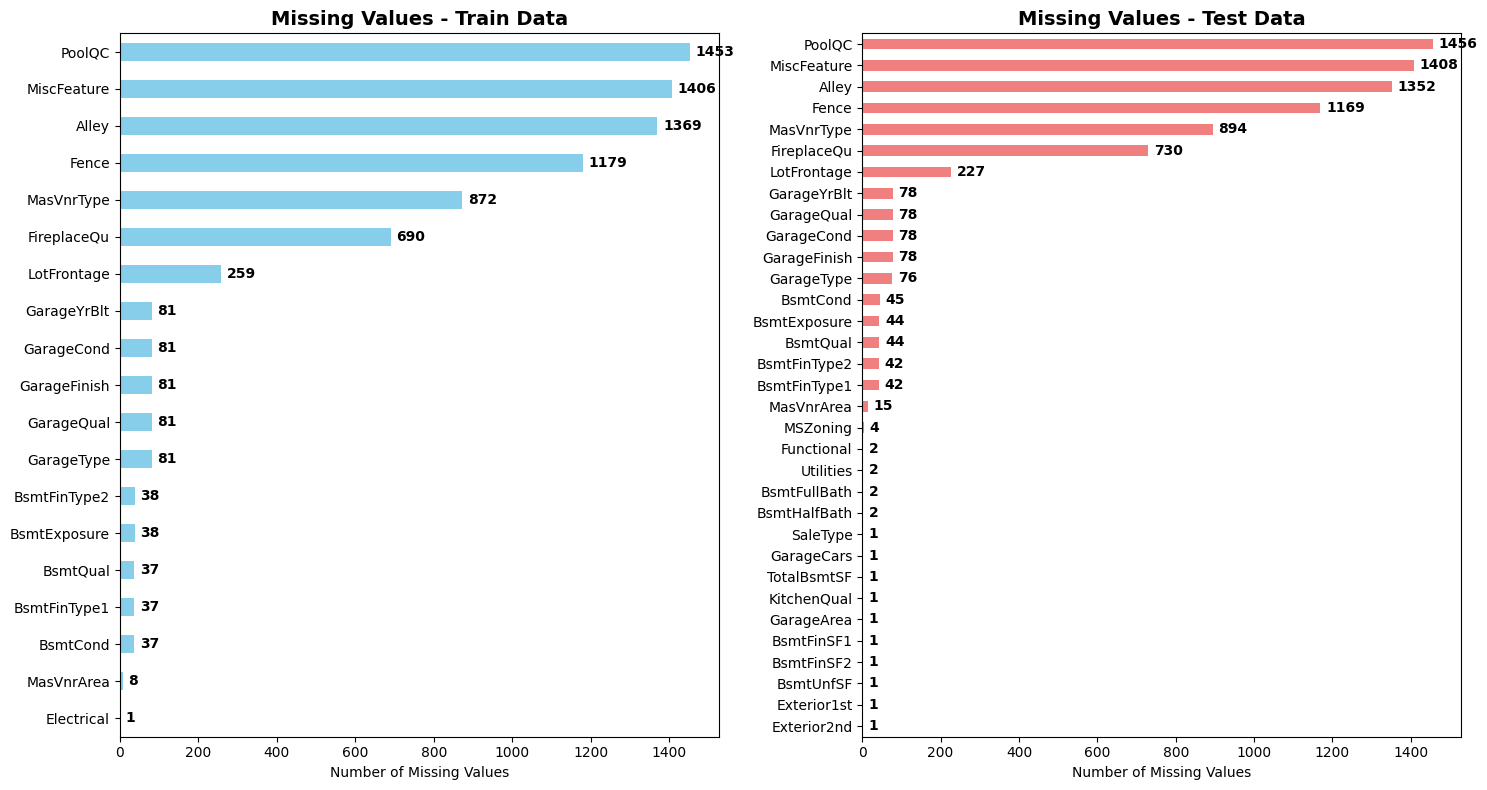

Số lượng cột bị thiếu giá trị trong train data: 19
Số lượng cột bị thiếu giá trị trong test data: 33


In [87]:
# Tính missing values
missing_train = df_train.isnull().sum()
missing_test = df_test.isnull().sum()

# Lọc chỉ các cột có missing values
missing_train = missing_train[missing_train > 0]
missing_test = missing_test[missing_test > 0]

# Sắp xếp theo thứ tự giảm dần để dễ nhìn
missing_train = missing_train.sort_values(ascending=True)
missing_test = missing_test.sort_values(ascending=True)

# Vẽ biểu đồ ngang
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Train data
if len(missing_train) > 0:
    missing_train.plot.barh(ax=ax1, color='skyblue')
    ax1.set_title('Missing Values - Train Data', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Missing Values')
    
    # Thêm giá trị lên cột
    for i, v in enumerate(missing_train):
        ax1.text(v + max(missing_train.values)*0.01, i, str(v), 
                va='center', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
             transform=ax1.transAxes, fontsize=12)

# Test data
if len(missing_test) > 0:
    missing_test.plot.barh(ax=ax2, color='lightcoral')
    ax2.set_title('Missing Values - Test Data', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Missing Values')
    
    # Thêm giá trị lên cột
    for i, v in enumerate(missing_test):
        ax2.text(v + max(missing_test.values)*0.01, i, str(v), 
                va='center', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
             transform=ax2.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

print("Số lượng cột bị thiếu giá trị trong train data:", len(missing_train))
print("Số lượng cột bị thiếu giá trị trong test data:", len(missing_test))

In [88]:
df = df_train.copy()

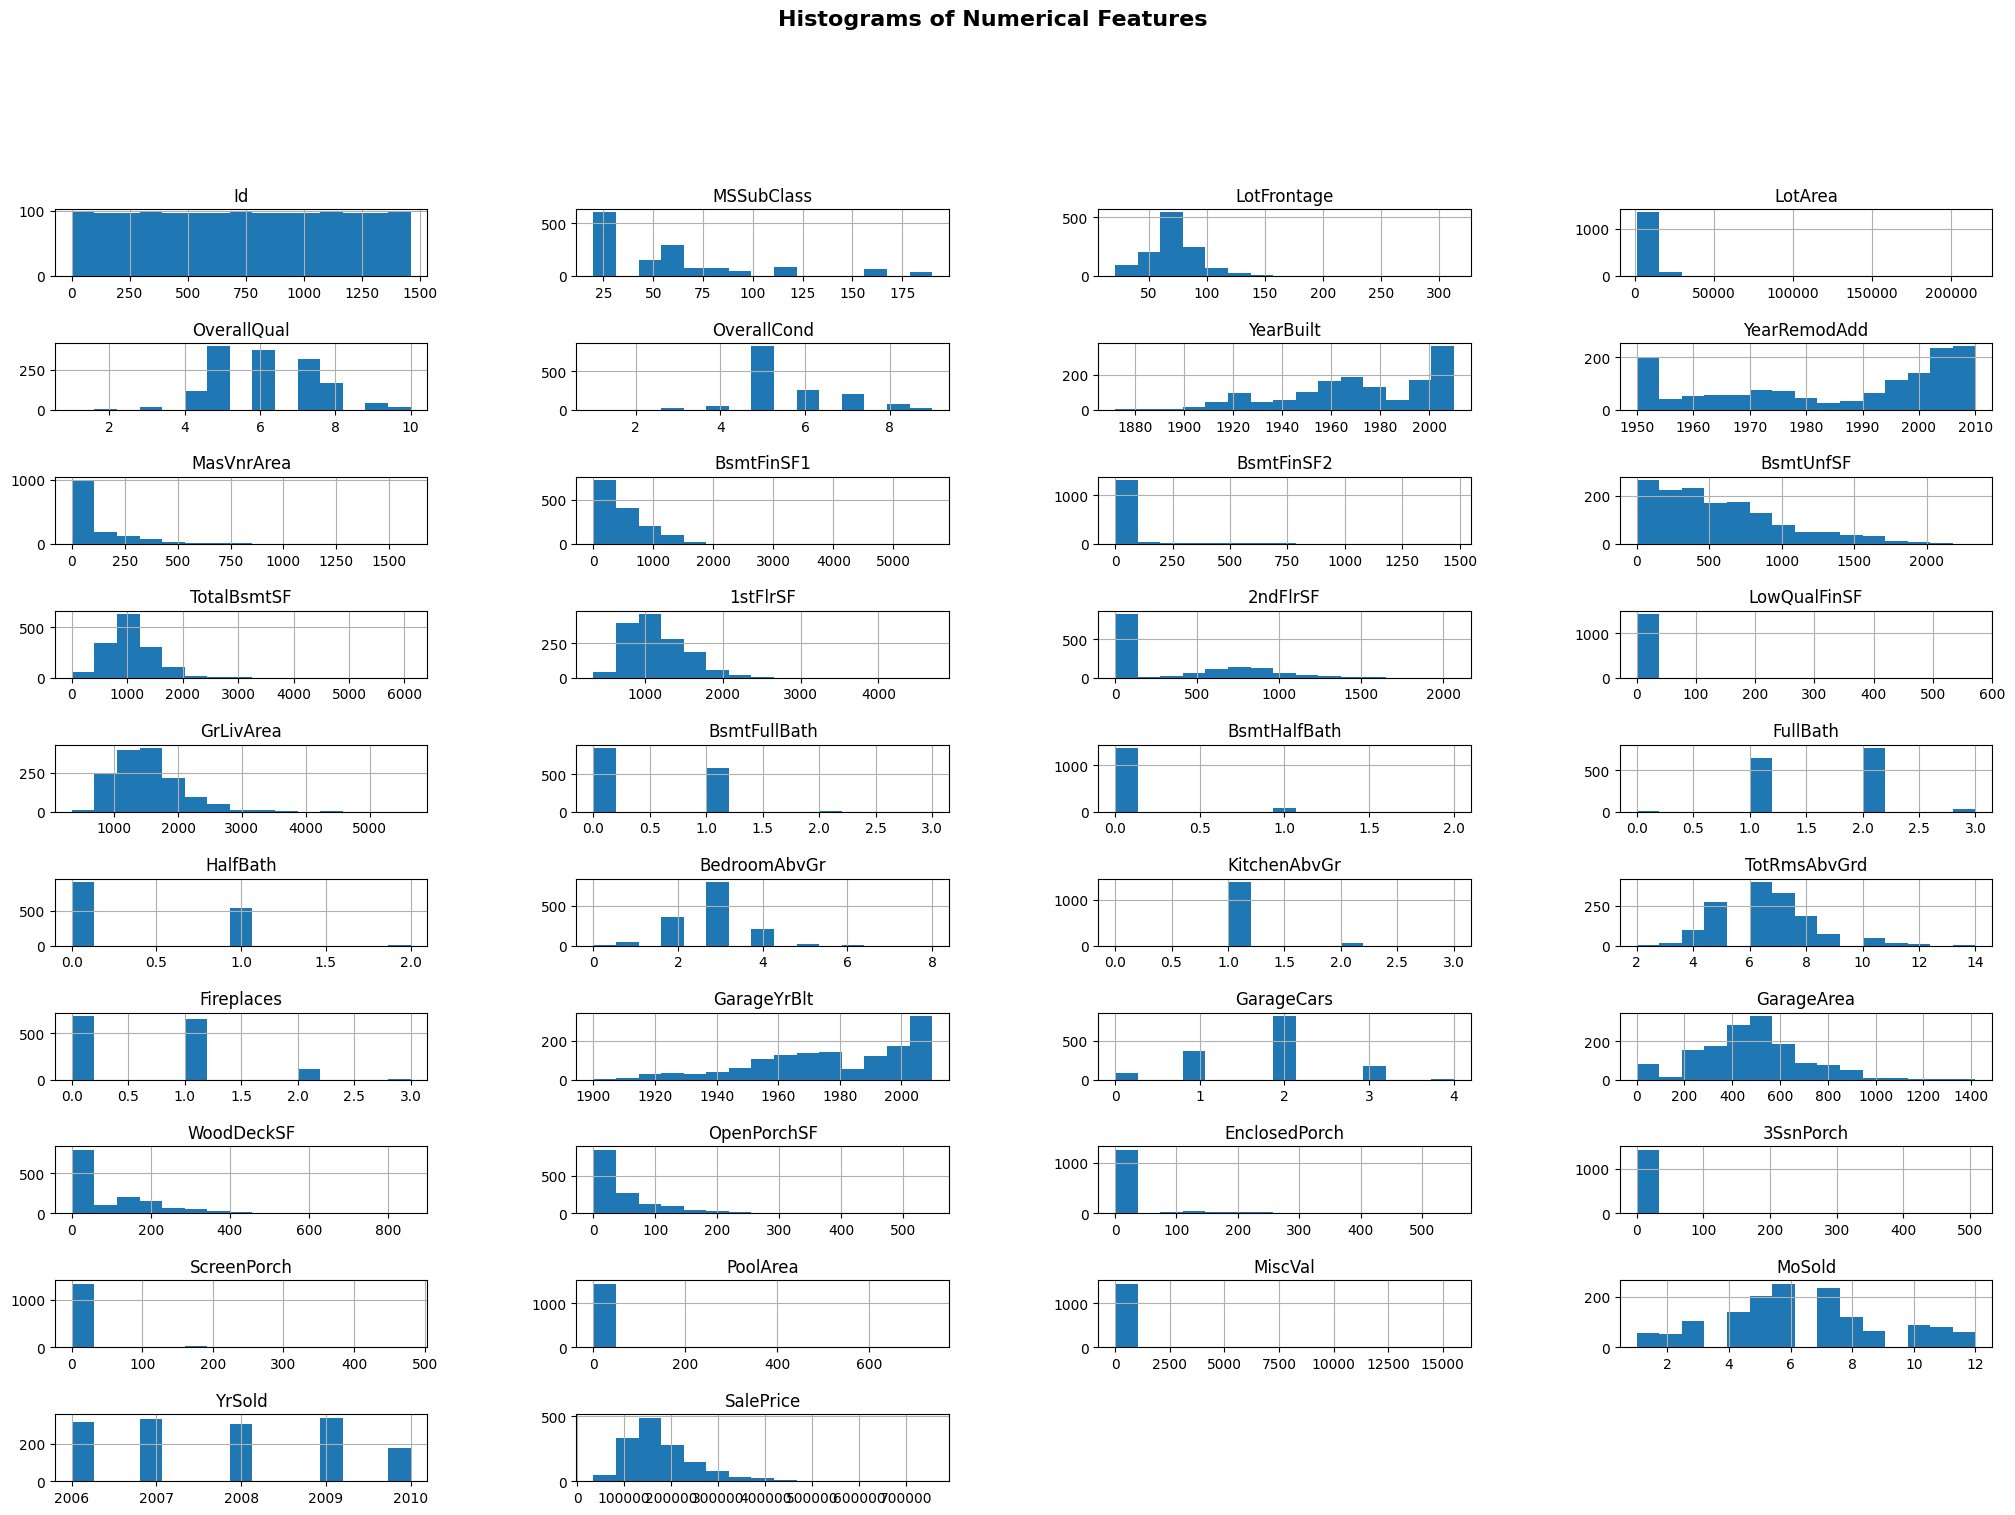

In [89]:
# Biểu đồ histogram cho các biến số
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(bins=15, figsize=(25, 20), layout=(12, 4))

plt.suptitle('Histograms of Numerical Features', fontsize=16, fontweight='bold')

# Điều chỉnh khoảng cách giữa các subplot
plt.subplots_adjust(
    wspace=0.4,    # Khoảng cách ngang giữa các subplot (tăng lên)
    hspace=1.0     # Khoảng cách dọc giữa các subplot (tăng lên)
)

plt.show()

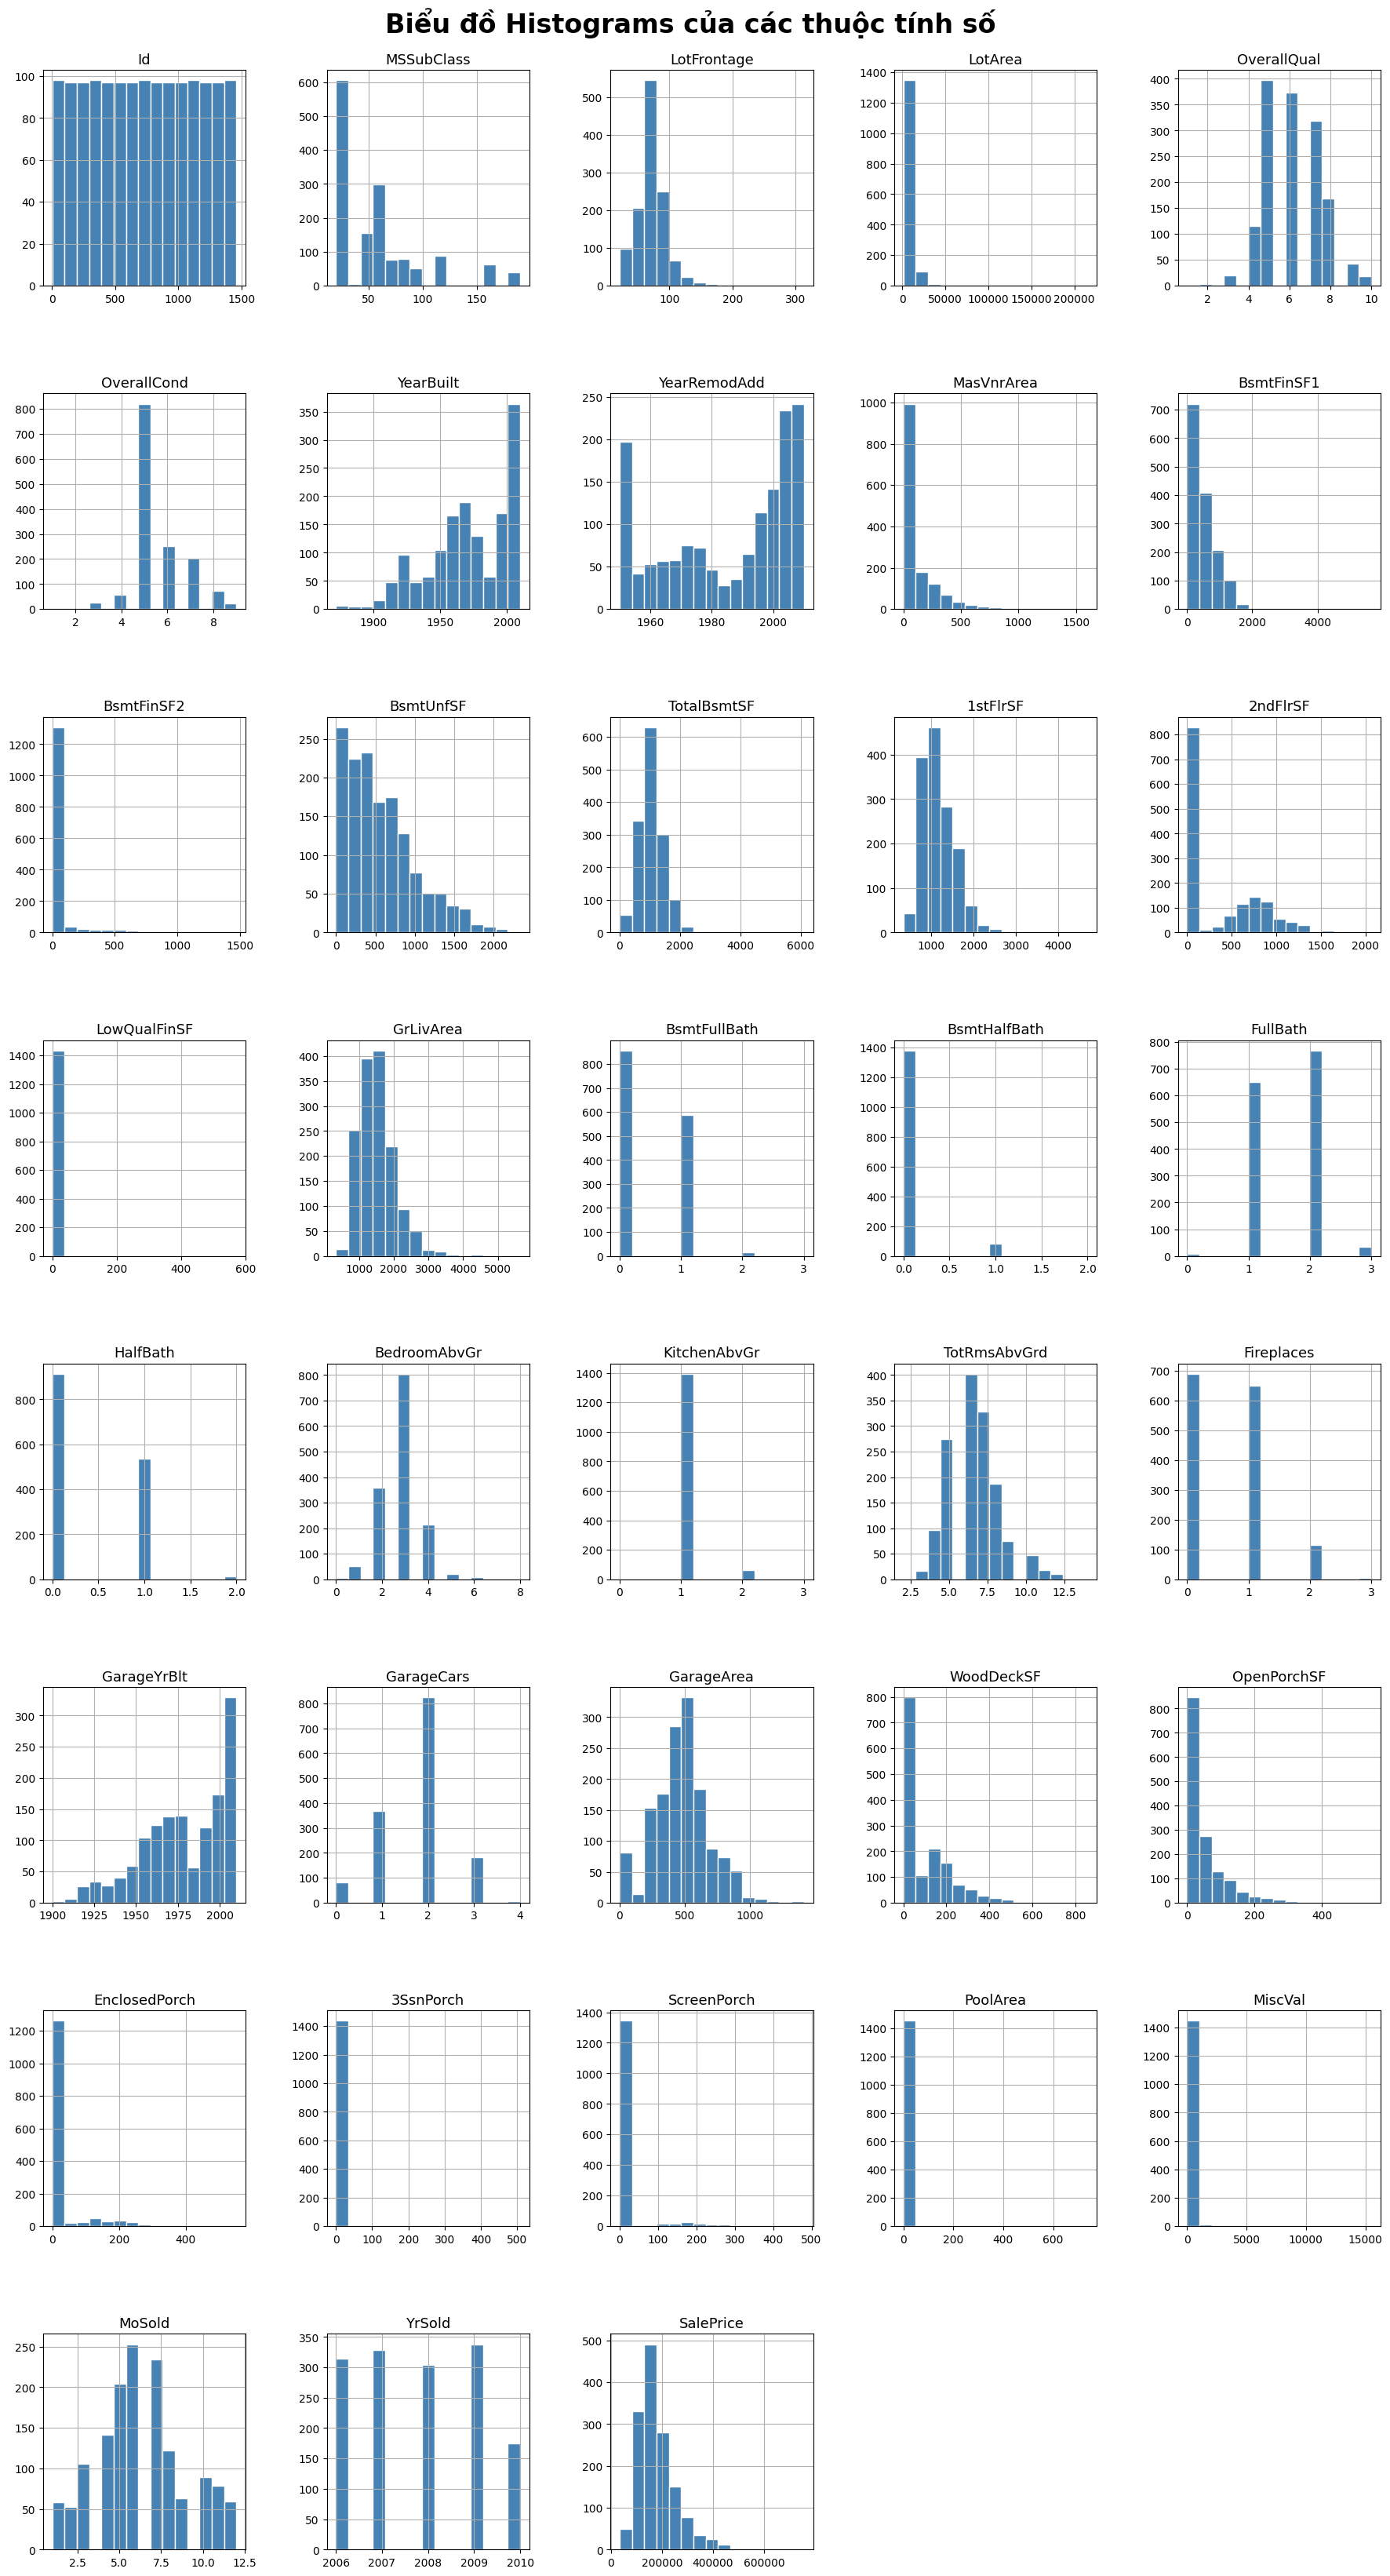

In [90]:
# ...existing code...
# Biểu đồ histogram cho các biến số
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_features = len(num_cols)
cols = 5                       # số cột giữ nguyên
rows = math.ceil(n_features / cols)

# Tăng chiều cao: mỗi hàng ~5 đơn vị => height = rows * 5
# ...existing code...
fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 5))

for i, col in enumerate(num_cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    df[col].hist(bins=15, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=13)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

# Ẩn subplot thừa
total_axes = rows * cols
for j in range(n_features, total_axes):
    r = j // cols
    c = j % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.set_visible(False)

# Thu gọn khoảng trắng và kéo title xuống
plt.subplots_adjust(wspace=0.4, hspace=0.5, top=0.90)  # giảm top từ mặc định ~0.92
fig.suptitle('Biểu đồ Histograms của các thuộc tính số', fontsize=24, fontweight='bold', y=0.92)  # y < 1 kéo gần biểu đồ
plt.show()
# ...existing code...
# ...existing code...

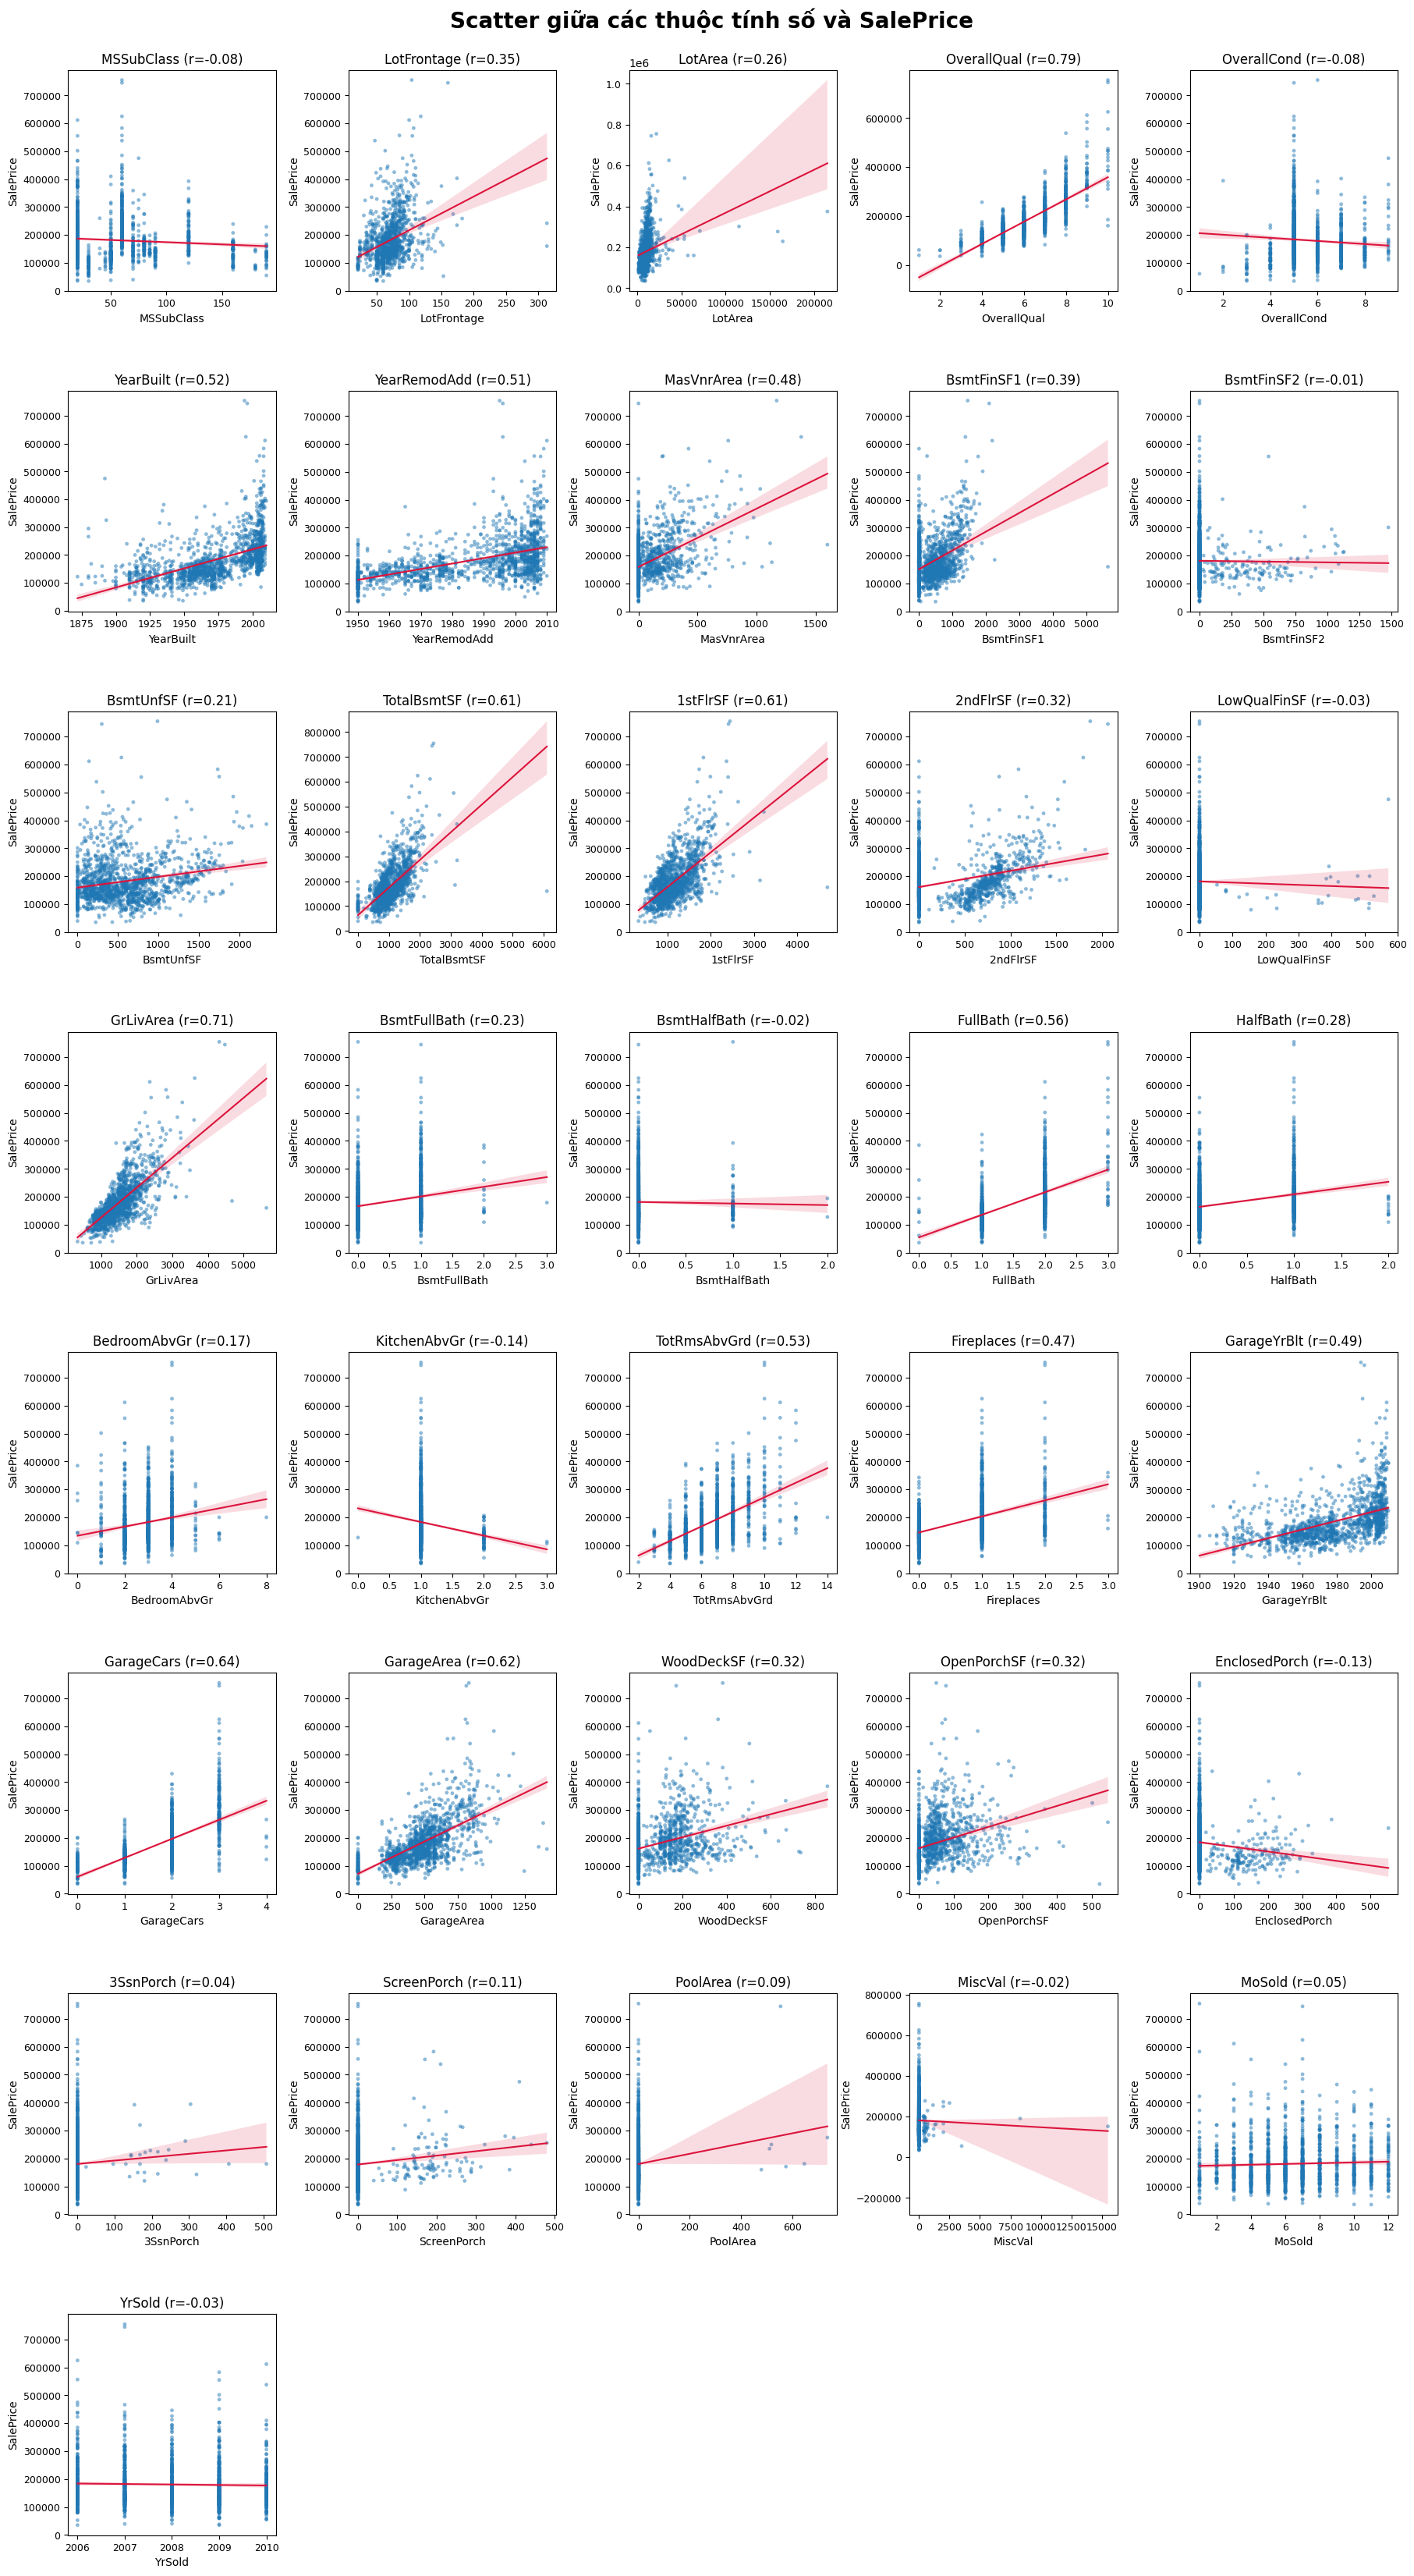

In [118]:
# ...existing code...
# Biểu đồ scatter giữa các biến số và SalePrice
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Loại bỏ cột đích và các cột không hữu ích như Id (nếu có)
num_cols = [c for c in num_cols if c not in ['SalePrice', 'Id']]

n_features = len(num_cols)
cols = 5
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 5))
axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

for i, col in enumerate(num_cols):
    ax = axes[i]
    tmp = df[[col, 'SalePrice']].dropna()
    # Vẽ scatter + đường xu hướng tuyến tính
    sns.regplot(
        x=col, y='SalePrice', data=tmp, ax=ax,
        scatter_kws={'s': 12, 'alpha': 0.5, 'edgecolor': 'none'},
        line_kws={'color': 'crimson', 'linewidth': 1.5}
    )
    # Tính tương quan Pearson
    r = tmp[col].corr(tmp['SalePrice'])
    ax.set_title(f'{col} (r={r:.2f})', fontsize=12)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

# Ẩn subplot thừa
total_axes = rows * cols
for j in range(n_features, total_axes):
    axes[j].set_visible(False)

# Thu gọn khoảng trắng và kéo title xuống gần subplot
plt.subplots_adjust(wspace=0.35, hspace=0.45, top=0.90)
fig.suptitle('Scatter giữa các thuộc tính số và SalePrice', fontsize=20, fontweight='bold', y=0.92)
plt.show()
# ...existing code...

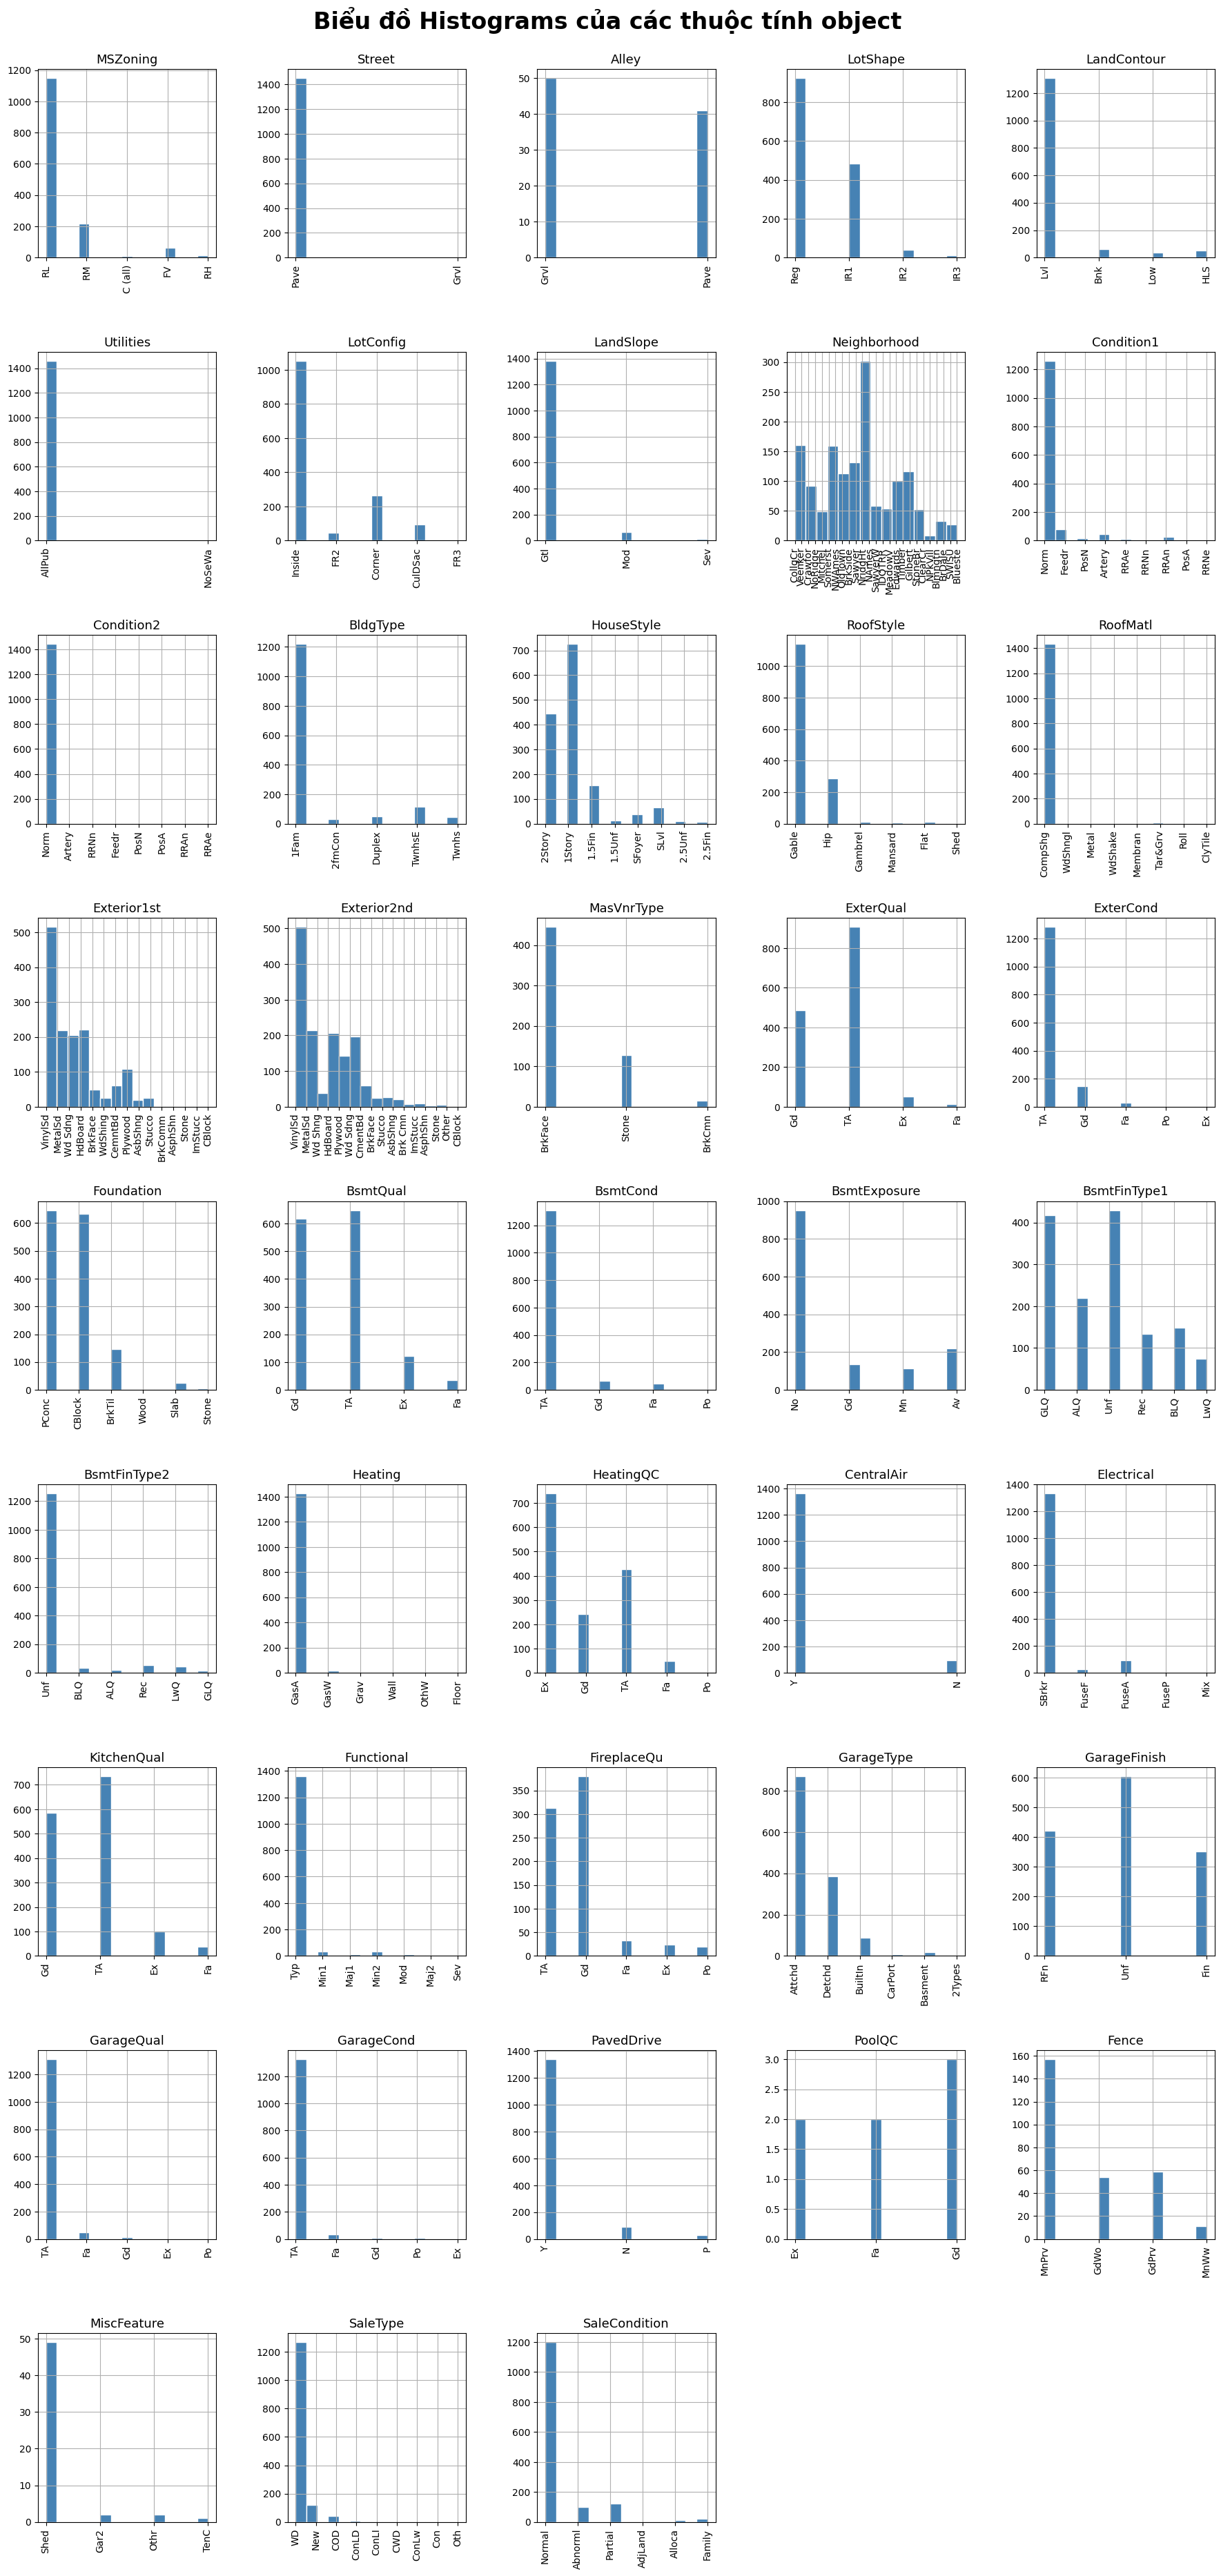

In [91]:
# ...existing code...
# Biểu đồ histogram cho các biến số
import math

num_cols = df.select_dtypes(include=['object']).columns
n_features = len(num_cols)
cols = 5                       # số cột giữ nguyên
rows = math.ceil(n_features / cols)

# Tăng chiều cao: mỗi hàng ~5 đơn vị => height = rows * 5
# ...existing code...
fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 5))

for i, col in enumerate(num_cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    df[col].hist(bins=15, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=13)
    ax.tick_params(axis='x', labelsize=10, labelrotation=90)
    ax.tick_params(axis='y', labelsize=10)

# Ẩn subplot thừa
total_axes = rows * cols
for j in range(n_features, total_axes):
    r = j // cols
    c = j % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.set_visible(False)

# Thu gọn khoảng trắng và kéo title xuống
plt.subplots_adjust(wspace=0.4, hspace=0.5, top=0.90)  # giảm top từ mặc định ~0.92
fig.suptitle('Biểu đồ Histograms của các thuộc tính object', fontsize=24, fontweight='bold', y=0.92)  # y < 1 kéo gần biểu đồ
plt.show()
# ...existing code...
# ...existing code...

In [92]:
# Nhận xét sơ bộ về phân phối các biến số
print("Nhận xét sơ bộ về phân phối các biến số:")
print("- Nhiều biến số có phân phối lệch phải, với một số biến có đuôi dài.")
print("- Một số biến số có phân phối gần như chuẩn, trong khi một số khác có phân phối đa mô.")
print("- Có một số biến số có giá trị ngoại lai rõ ràng, cần được xem xét kỹ hơn trong các bước phân tích tiếp theo.")
# Thiết lập hiển thị đầy đủ cho DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.describe()


Nhận xét sơ bộ về phân phối các biến số:
- Nhiều biến số có phân phối lệch phải, với một số biến có đuôi dài.
- Một số biến số có phân phối gần như chuẩn, trong khi một số khác có phân phối đa mô.
- Có một số biến số có giá trị ngoại lai rõ ràng, cần được xem xét kỹ hơn trong các bước phân tích tiếp theo.


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [93]:
df.describe(include='all')


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,588,1452.000000,1460,1460,1460,1423,1423,1422,1423,1460.000000,1422,1460.000000,1460.000000,1460.000000,1460,1460,1460,1459,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460.000000,1460,1460.000000,770,1379,1379.000000,1379,1460.000000,1460.000000,1379,1379,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,5,3,25,9,8,5,8,NaN,NaN,NaN,NaN,6,8,15,16,3,NaN,4,5,6,4,4,4,6,NaN,6,NaN,NaN,NaN,6,5,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,NaN,5,6,NaN,3,NaN,NaN,5,5,3,NaN,NaN,NaN,NaN,NaN,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,BrkFace,NaN,TA,TA,PConc,TA,TA,No,Unf,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,Gd,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,NaN,NaN,NaN,NaN,1141,1434,515,504,445,NaN,906,1282,647,649,1311,953,430,NaN,1256,NaN,NaN,NaN,1428,741,1365,1334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735,NaN,1360,NaN,380,870,NaN,605,NaN,NaN,1311,1326,1340,NaN,NaN,NaN,NaN,NaN,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.099315,5.575342,1971.267808,1984.865753,NaN,NaN,NaN,NaN,NaN,103.685262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,443.639726,NaN,46.549315,567.240411,1057.429452,NaN,NaN,NaN,NaN,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,NaN,6.517808,NaN,0.613014,NaN,NaN,1978.506164,NaN,1.767123,472.980137,NaN,NaN,NaN,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.382997,1.112799,30.202904,20.645407,NaN,NaN,NaN,NaN,NaN,181.066207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456.098091,NaN,161.319273,441.866955,438.705324,NaN,NaN,NaN,NaN,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,NaN,1.625393,NaN,0.644666,NaN,NaN,24.689725,NaN,0.747315,213.804841,NaN,NaN,NaN,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1872.000000,1950.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,NaN,0.000000,NaN,NaN,1900.000000,N

In [94]:
# Nhận

In [95]:
df['Street'].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [96]:
df['Alley'].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

array(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BedroomAbvGr', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF',
       'EnclosedPorch', 'Fireplaces', 'FullBath', 'GarageArea',
       'GarageCars', 'GarageYrBlt', 'GrLivArea', 'HalfBath', 'Id',
       'KitchenAbvGr', 'LotArea', 'LotFrontage', 'LowQualFinSF',
       'MSSubClass', 'MasVnrArea', 'MiscVal', 'MoSold', 'OpenPorchSF',
       'OverallCond', 'OverallQual', 'PoolArea', 'SalePrice',
       'ScreenPorch', 'TotRmsAbvGrd', 'TotalBsmtSF', 'WoodDeckSF',
       'YearBuilt', 'YearRemodAdd', 'YrSold'], dtype=object)

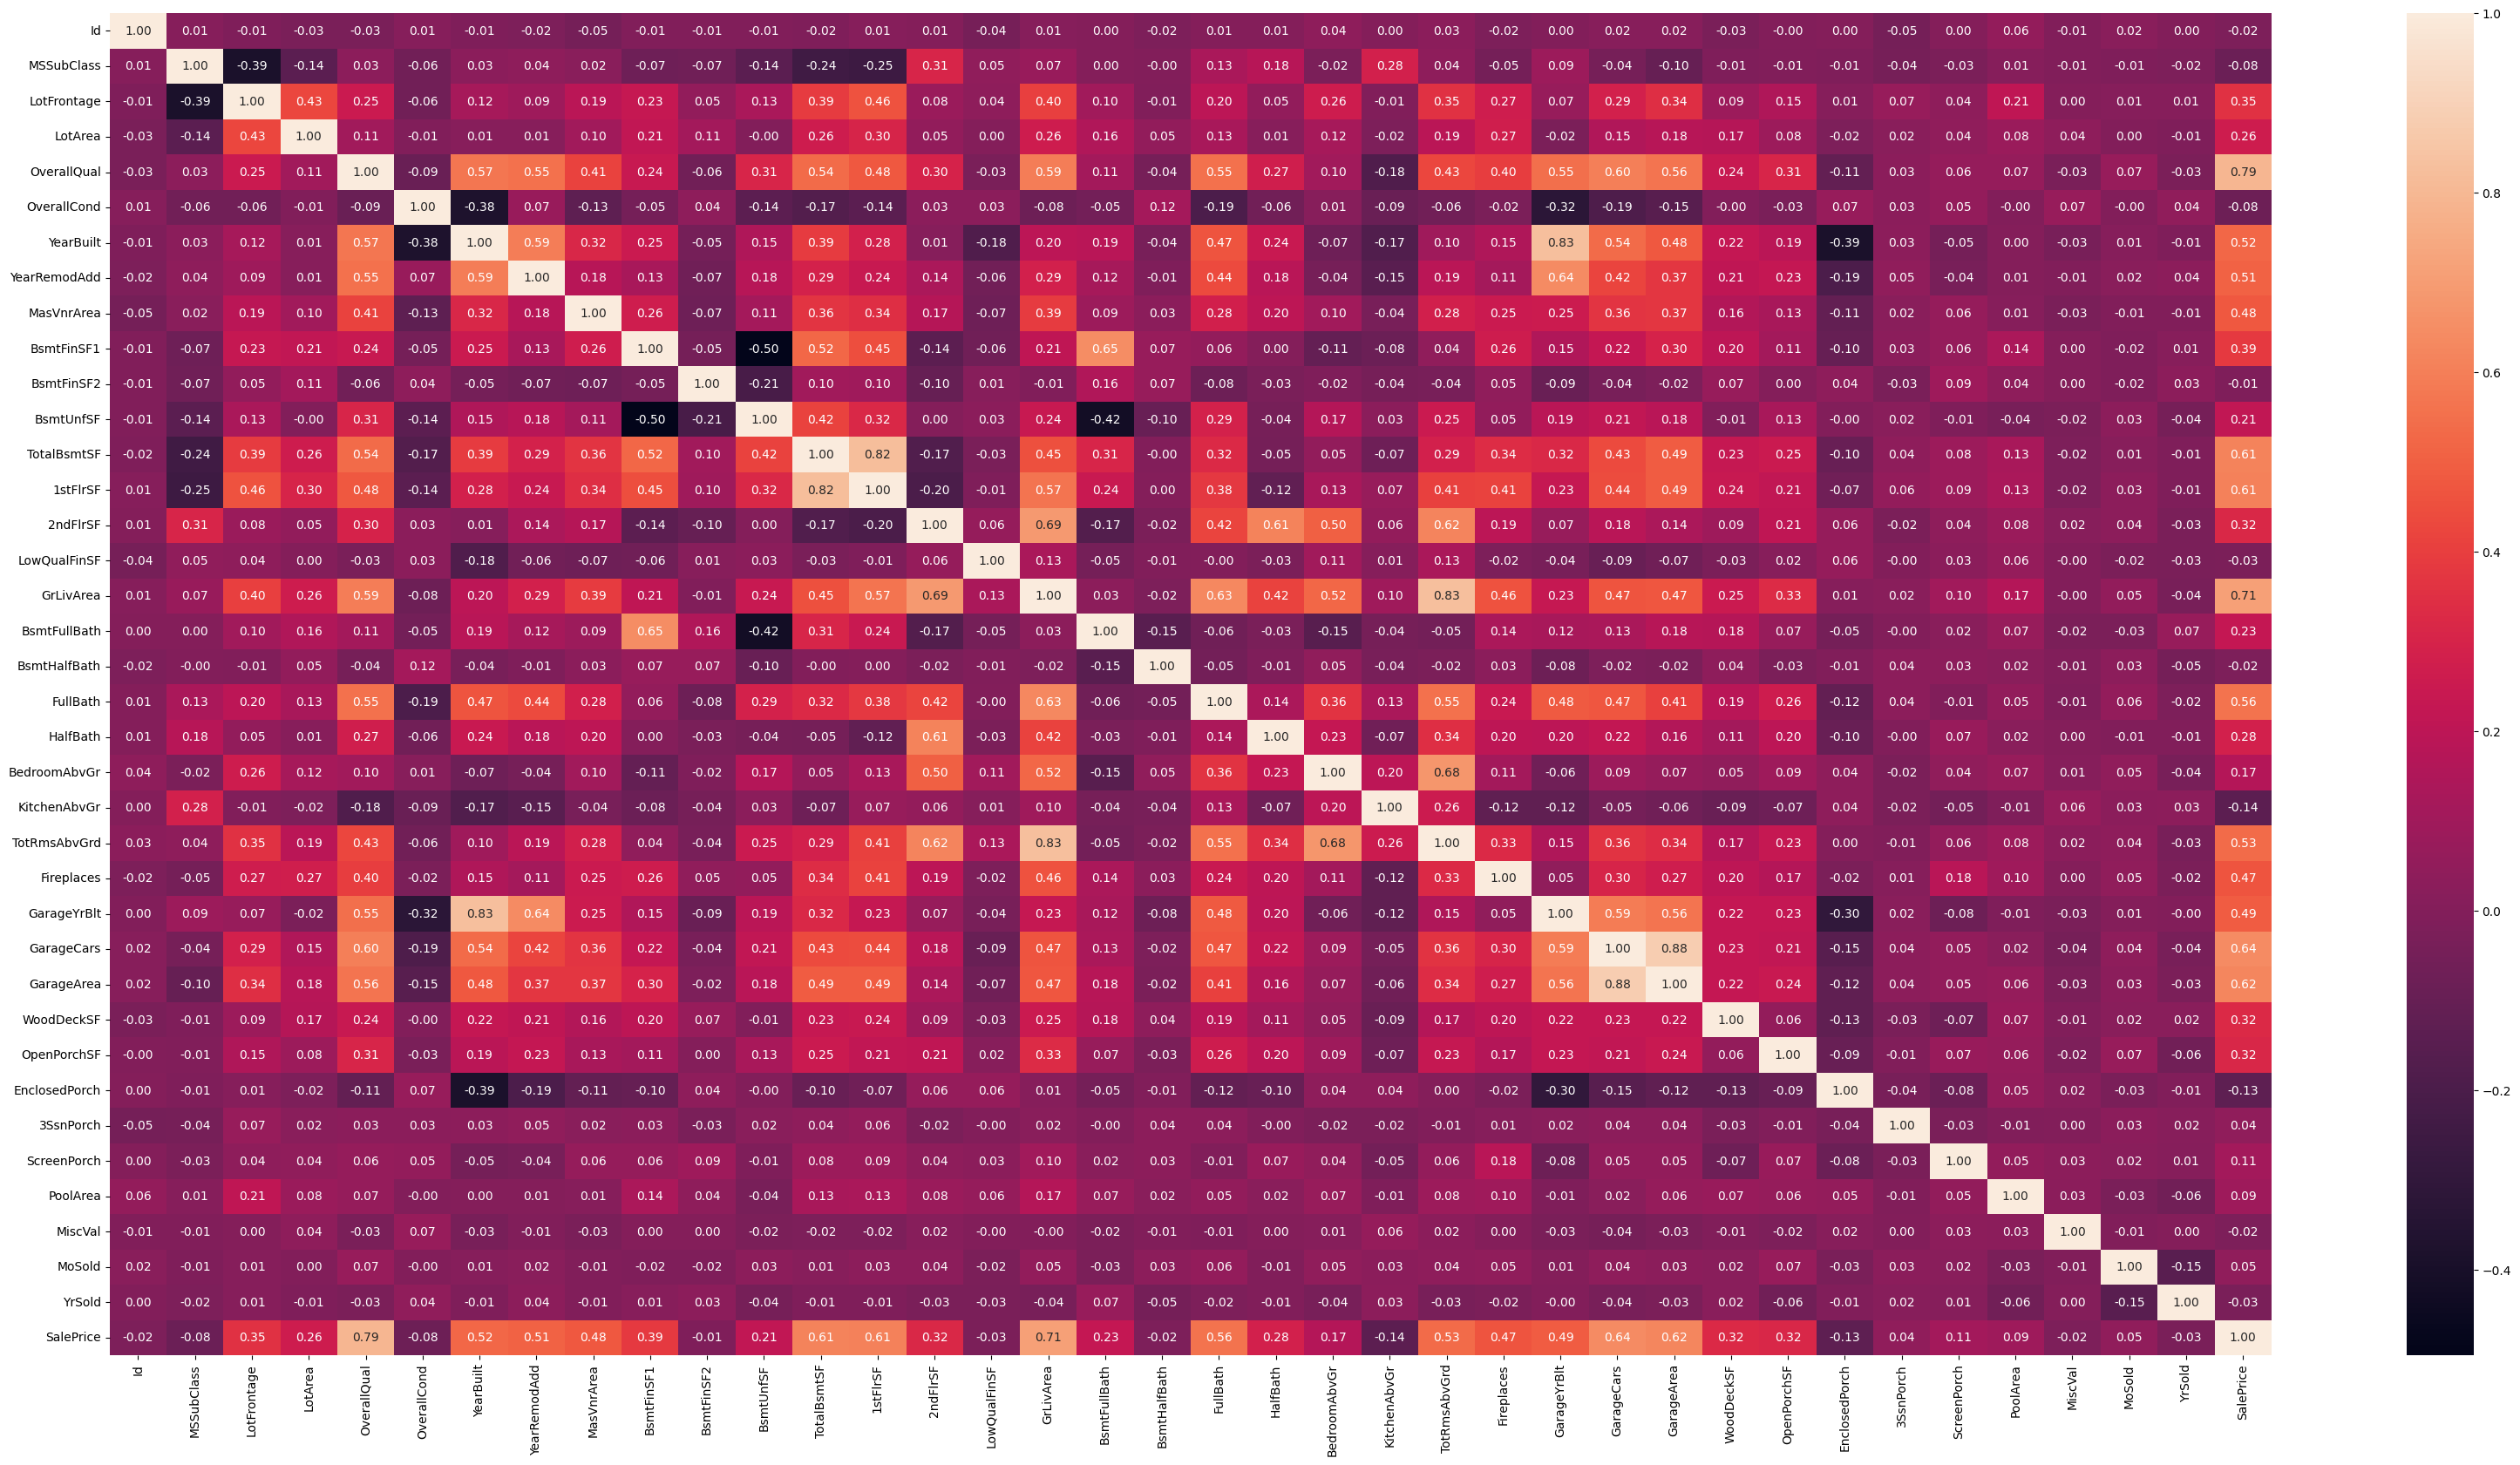

In [97]:
feature_number = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(40, 20))
sns.heatmap(df[feature_number].corr(), annot=True, fmt=".2f")
np.unique(feature_number)

In [98]:
# đ

## Drop các cột có số lượng missing vượt quá 40%


In [99]:
def drop_missing_columns(df, threshold=0.4):
    missing_ratio = df.isna().mean()
    missing_columns = missing_ratio[missing_ratio > threshold].index.tolist()
    print(f'Dropping {len(missing_columns)} columns with more than {threshold*100}% missing values.')
    print(f'Columns to drop: {missing_columns}')
    
    # Drop columns and return the modified DataFrame
    df_dropped = df.drop(columns=missing_columns)
    return df_dropped

In [100]:
df_output = df_train.copy()

In [101]:
df_output = drop_missing_columns(df_output, threshold=0.4)

Dropping 6 columns with more than 40.0% missing values.
Columns to drop: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


## Drop các cột có nhiều giá trị 0


In [102]:
def drop_zero_columns(df, threshold=0.5):
    # Calculate ratio of zeros in each column
    zero_ratio = (df == 0).astype(int).mean()
    zero_columns = zero_ratio[zero_ratio > threshold].index.tolist()
    
    print(f'Dropping {len(zero_columns)} columns with more than {threshold*100}% zero values.')
    print(f'Columns to drop: {zero_columns}')
    
    # Drop the columns
    df_dropped = df.drop(columns=zero_columns)
    return df_dropped

In [103]:
df_output = drop_zero_columns(df_output, threshold=0.5)

Dropping 13 columns with more than 50.0% zero values.
Columns to drop: ['MasVnrArea', 'BsmtFinSF2', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'WoodDeckSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


In [ ]:
df_output

In [105]:
# d

## Lọc ra các cột loại number có độ tương quan cao đối với SalePrice (>0.4)


In [106]:
def engineer_number_columns(df):
    ## Kiểm tra độ tương quan giữa các cột number với SalePrice
    numeric_cols = df_output.select_dtypes(include=[np.number]).columns.tolist()
    correlations = df_output[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
    feature_number = correlations[correlations.abs() > 0.4].index.tolist()
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_output[feature_number].corr(), annot=True, fmt=".2f", cmap='coolwarm')
    np.unique(feature_number)
    return feature_number

## Lọc ra các cột loại object có độ phân bố ít lệch


In [107]:
def engineer_object_columns(df):
    ## Kiểm tra độ phân bố của các cột object
    object_cols = df_output.select_dtypes(include=['object']).columns.tolist()
    skewed_features = []
    for col in object_cols:
        value_counts = df_output[col].value_counts(normalize=True)
        max_proportion = value_counts.max()
        if max_proportion < 0.7:  # Giả sử ngưỡng là 80%
            skewed_features.append(col)
    print(f'Features with less skewed distribution: {skewed_features}')
    return skewed_features

In [108]:
def engineer_object_columns1(df):
    features_ob = ['BsmtExposure','BsmtFinType1','BsmtQual','Exterior1st','Exterior2nd','ExterQual','Foundation','GarageFinish','GarageType','HeatingQC','HouseStyle','KitchenQual','LandSlope','LotConfig','LotShape','MSZoning','Neighborhood','RoofStyle','SaleCondition','YrSold']
    return features_ob

In [109]:
from sklearn.preprocessing import LabelEncoder
def engineer_object_columns2(df, target_col='SalePrice'):
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    le = LabelEncoder()
    correlations = {}
    
    for col in object_cols:
        # Encode categorical column
        encoded_col = le.fit_transform(df[col].astype(str))
        # Calculate correlation with target
        corr = np.corrcoef(encoded_col, df[target_col])[0, 1]
        if abs(corr) > 0.2:
            correlations[col] = corr
    
    return correlations

Correlation of object columns with target:
Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
LotShape        -0.255580
BsmtExposure    -0.309043
HeatingQC       -0.400178
GarageType      -0.415283
GarageFinish    -0.549247
KitchenQual     -0.589189
BsmtQual        -0.620886
ExterQual       -0.636884
dtype: float64


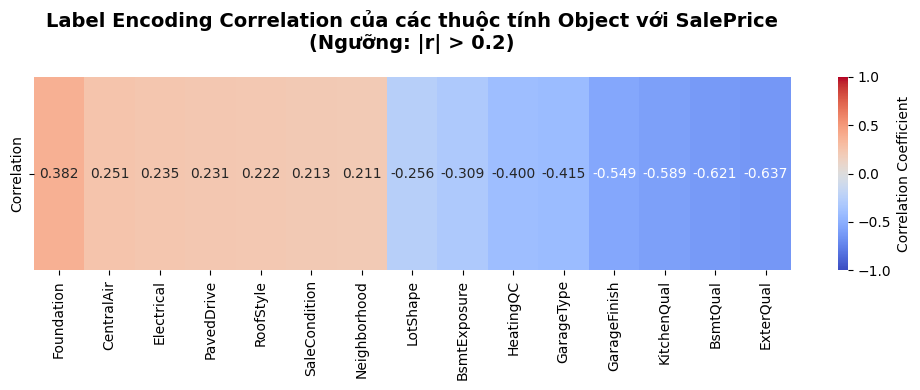


Tổng số biến categorical phân tích: 15
Biến có tương quan dương mạnh nhất: Foundation (r=0.382)
Biến có tương quan âm mạnh nhất: ExterQual (r=-0.637)


In [125]:
# Độ tương quan các cột object với SalePrice
def correlate_object_with_target(df, target_col='SalePrice', threshold=0.2, show_plot=True):
    correlations = engineer_object_columns2(df, target_col)
    
    # Convert to Series for easier handling
    corr_series = pd.Series(correlations).sort_values(ascending=False)
    print("Correlation of object columns with target:")
    print(corr_series)
    
    # Tạo heatmap nếu có dữ liệu
    if show_plot and len(corr_series) > 0:
        fig, ax = plt.subplots(figsize=(max(10, 0.5*len(corr_series)), 4))
        
        # Tạo DataFrame cho heatmap
        corr_df = pd.DataFrame([corr_series], index=['Correlation'])
        
        # Vẽ heatmap
        sns.heatmap(
            corr_df,
            annot=True,
            fmt=".3f",
            cmap='coolwarm',
            center=0,
            ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1,
            vmax=1
        )
        
        ax.set_title(f'Label Encoding Correlation của các thuộc tính Object với {target_col}\n(Ngưỡng: |r| > {threshold})', 
                    fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('')
        ax.set_ylabel('')
        
        plt.tight_layout()
        plt.show()
        
        # Thống kê
        print("\n" + "="*80)
        print(f"Tổng số biến categorical phân tích: {len(corr_series)}")
        print(f"Biến có tương quan dương mạnh nhất: {corr_series.idxmax()} (r={corr_series.max():.3f})")
        print(f"Biến có tương quan âm mạnh nhất: {corr_series.idxmin()} (r={corr_series.min():.3f})")
        print("="*80)
    
    return corr_series

# Gọi function
corr_result = correlate_object_with_target(df_output, target_col='SalePrice', threshold=0.2, show_plot=True)

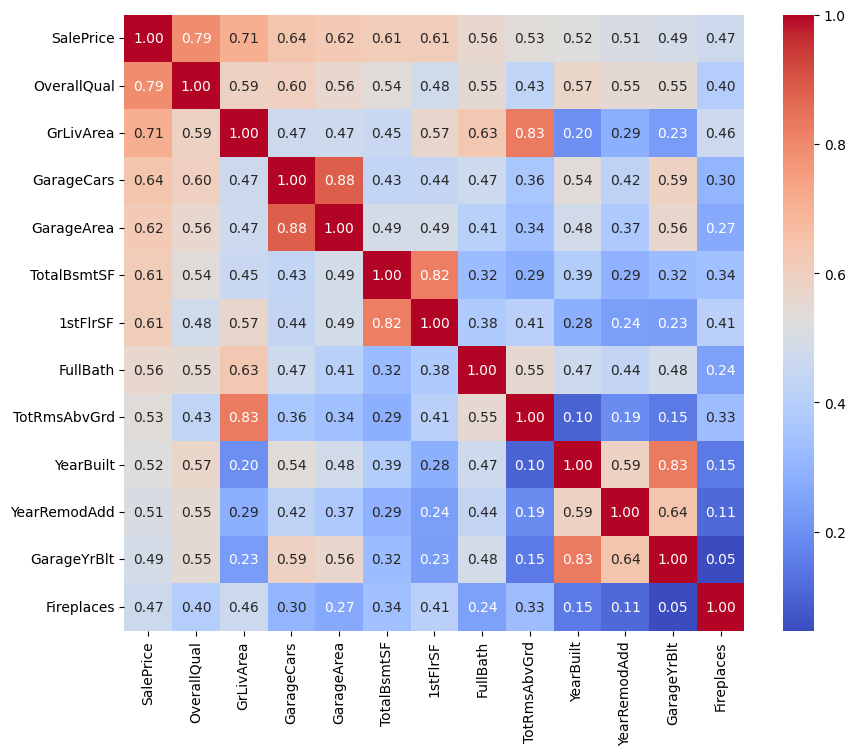

In [111]:
final_feature = engineer_number_columns(df_output) + list(engineer_object_columns2(df_output).keys())

# Lựa chọn các feature theo độ tương quan (number_column) và độ phân bố giá trị (object_column)


## Kiểm tra độ tương quan giữa các cột number với SalePrice


In [113]:
## Kiểm tra độ tương quan giữa các cột number với SalePrice
numeric_cols = df_output.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_output[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
correlations

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
OpenPorchSF     0.315856
LotArea         0.263843
BsmtUnfSF       0.214479
BedroomAbvGr    0.168213
MoSold          0.046432
Id             -0.021917
YrSold         -0.028923
OverallCond    -0.077856
MSSubClass     -0.084284
KitchenAbvGr   -0.135907
Name: SalePrice, dtype: float64

               Spearman     Spearman_p     ANOVA_F        ANOVA_p  n_levels
feature                                                                    
Neighborhood   0.755779  2.258361e-270   71.784865  1.558600e-225        25
ExterQual      0.684014  5.605572e-202  443.334831  1.439551e-204         4
KitchenQual    0.672849  4.400509e-193  407.806352  3.032213e-192         4
BsmtQual       0.664393  6.432049e-182  392.913506  9.610615e-186         4
GarageFinish   0.592256  2.494689e-131  250.962467   1.199117e-93         3
Foundation     0.573580  1.755079e-128  100.253851   5.791895e-91         6
GarageType     0.547721  8.783363e-109   71.522123   1.247154e-66         6
HeatingQC      0.491392   1.347224e-89  117.281347   5.041729e-68         5
Exterior1st    0.435284   1.485049e-68   23.369586   1.255003e-44        15
BsmtFinType1   0.426520   5.445484e-64   67.602175   1.807731e-63         6
Exterior2nd    0.423422   1.373259e-64   19.839259   1.804511e-43        16
MSZoning    

,Spearman,Spearman_p,ANOVA_F,ANOVA_p,n_levels
feature,,,,,
Neighborhood,0.755779,2.258361e-270,71.784865,1.558600e-225,25
ExterQual,0.684014,5.605572e-202,443.334831,1.439551e-204,4
KitchenQual,0.672849,4.400509e-193,407.806352,3.032213e-192,4
BsmtQual,0.664393,6.432049e-182,392.913506,9.610615e-186,4
GarageFinish,0.592256,2.494689e-131,250.962467,1.199117e-93,3
Foundation,0.573580,1.755079e-128,100.253851,5.791895e-91,6
GarageType,0.547721,8.783363e-109,71.522123,1.247154e-66,6
HeatingQC,0.491392,1.347224e-89,117.281347,5.041729e-68,5
Exterior1st,0.435284,1.485049e-68,23.369586,1.255003e-44,15


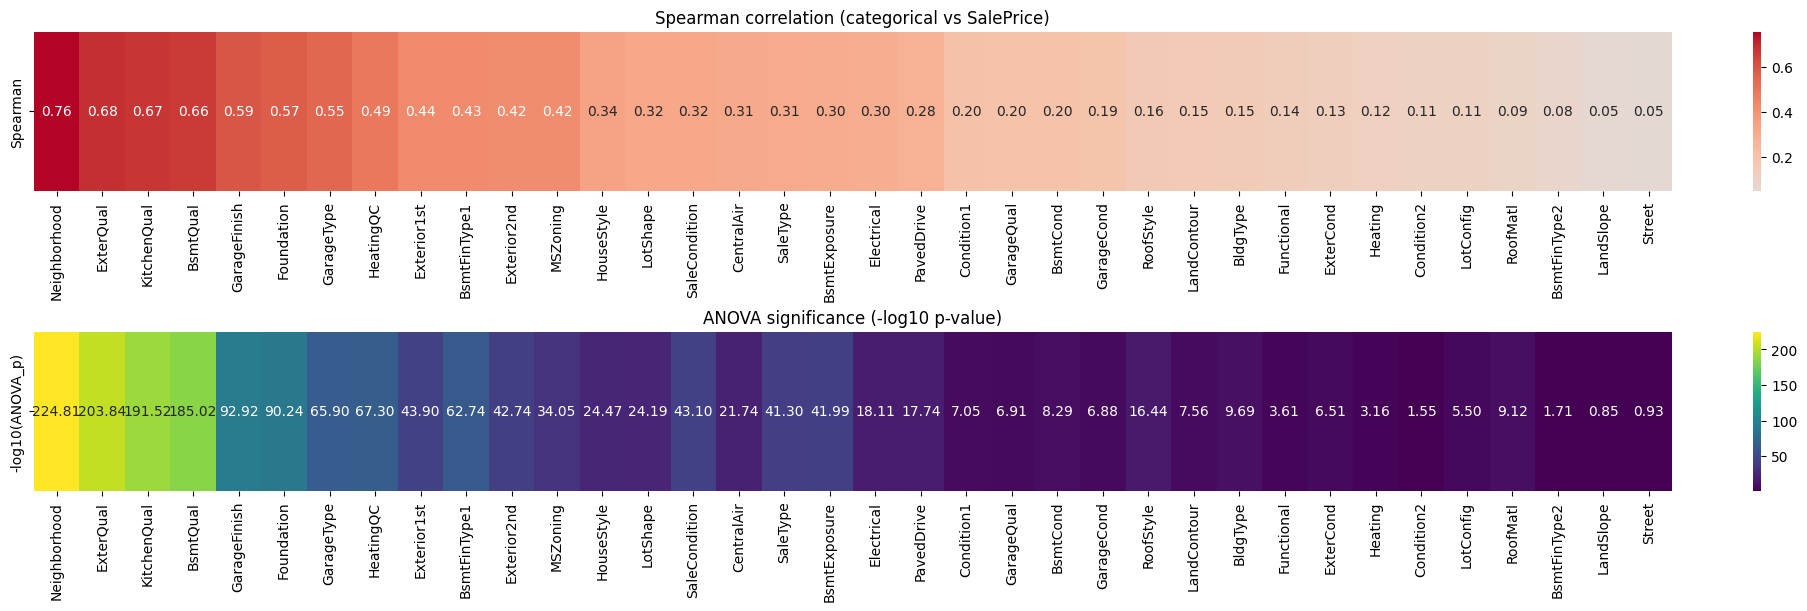

Biến phân loại gợi ý giữ lại (ngưỡng Spearman>|0.15| & p<0.05): ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish', 'Foundation', 'GarageType', 'HeatingQC', 'Exterior1st', 'BsmtFinType1', 'Exterior2nd', 'MSZoning', 'HouseStyle', 'LotShape', 'SaleCondition', 'CentralAir', 'SaleType', 'BsmtExposure', 'Electrical', 'PavedDrive', 'Condition1', 'GarageQual', 'BsmtCond', 'GarageCond', 'RoofStyle', 'LandContour', 'BldgType']


In [123]:
# ...existing code...
# Phân tích mối quan hệ giữa các biến phân loại (object) và SalePrice bằng Spearman & ANOVA
# Load libraries
# Load libraries
import os, sys
from IPython.display import display  # Sửa dòng này
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from scipy.stats import f_oneway, spearmanr

def analyze_categorical_vs_target(df, cat_cols, target='SalePrice', min_groups=2, min_group_size=2):
    records = []
    for col in cat_cols:
        if col == target:
            continue
        s = df[[col, target]].dropna()
        if s[col].nunique() < min_groups:
            continue
        
        # Mã hóa thứ hạng dựa trên mean(target) theo nhóm để Spearman có ý nghĩa hơn
        mean_target = s.groupby(col)[target].mean().sort_values()
        rank_map = {k: r for r, k in enumerate(mean_target.index, start=1)}
        encoded = s[col].map(rank_map)
        if encoded.nunique() < 2:
            continue
        spearman_val, spearman_p = spearmanr(encoded, s[target])
        
        # ANOVA: chỉ lấy các nhóm có đủ kích thước
        groups = [g[target].values for _, g in s.groupby(col) if g[target].notna().shape[0] >= min_group_size]
        if len(groups) < min_groups:
            continue
        try:
            f_stat, p_val = f_oneway(*groups)
        except Exception:
            f_stat, p_val = np.nan, np.nan
        
        records.append({
            'feature': col,
            'Spearman': spearman_val,
            'Spearman_p': spearman_p,
            'ANOVA_F': f_stat,
            'ANOVA_p': p_val,
            'n_levels': s[col].nunique()
        })
    return pd.DataFrame(records).set_index('feature').sort_values('Spearman', ascending=False)

# Chọn các cột phân loại (object). Có thể bổ sung thêm các cột đã mã hóa thủ công nếu cần.
cat_columns = df_output.select_dtypes(include=['object']).columns.tolist()
cat_result = analyze_categorical_vs_target(df_output, cat_columns, target='SalePrice')

# Hiển thị kết quả
print(cat_result)

display(cat_result)

# Tạo hai heatmap: (1) Spearman, (2) -log10(p ANOVA)
if not cat_result.empty:
    fig, axes = plt.subplots(2, 1, figsize=(max(10, 0.5*len(cat_result)), 6), constrained_layout=True)

    # Heatmap Spearman
    sns.heatmap(
        pd.DataFrame([cat_result['Spearman']], index=['Spearman']),
        annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=axes[0]
    )
    axes[0].set_title('Spearman correlation (categorical vs SalePrice)')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')

    # Heatmap -log10(p) của ANOVA (giá trị lớn => ý nghĩa thống kê mạnh)
    anova_logp = -np.log10(cat_result['ANOVA_p'].replace(0, 1e-300))
    sns.heatmap(
        pd.DataFrame([anova_logp], index=['-log10(ANOVA_p)']),
        annot=True, fmt=".2f", cmap='viridis', ax=axes[1]
    )
    axes[1].set_title('ANOVA significance (-log10 p-value)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')

    # Thêm ngưỡng ý nghĩa (p=0.05 => -log10≈1.30)
    axes[1].axhline(y=0, color='white', linewidth=0)  # giữ layout
    plt.show()
else:
    print("Không có biến phân loại hợp lệ để phân tích.")

# Gợi ý lọc ra các biến mạnh (ví dụ Spearman>|0.15| và p ANOVA < 0.05)
strong_cats = cat_result[
    (cat_result['Spearman'].abs() > 0.15)
].index.tolist()
print("Biến phân loại gợi ý giữ lại (ngưỡng Spearman>|0.15| & p<0.05):", strong_cats)
# ...existing code...

## Lọc ra các feature_number có độ tương quan hơn 0.4 so với SalePrice


array(['1stFlrSF', 'BedroomAbvGr', 'BsmtFinSF1', 'BsmtUnfSF',
       'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars',
       'GarageYrBlt', 'GrLivArea', 'KitchenAbvGr', 'LotArea',
       'LotFrontage', 'OpenPorchSF', 'OverallQual', 'SalePrice',
       'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd'],
      dtype='<U12')

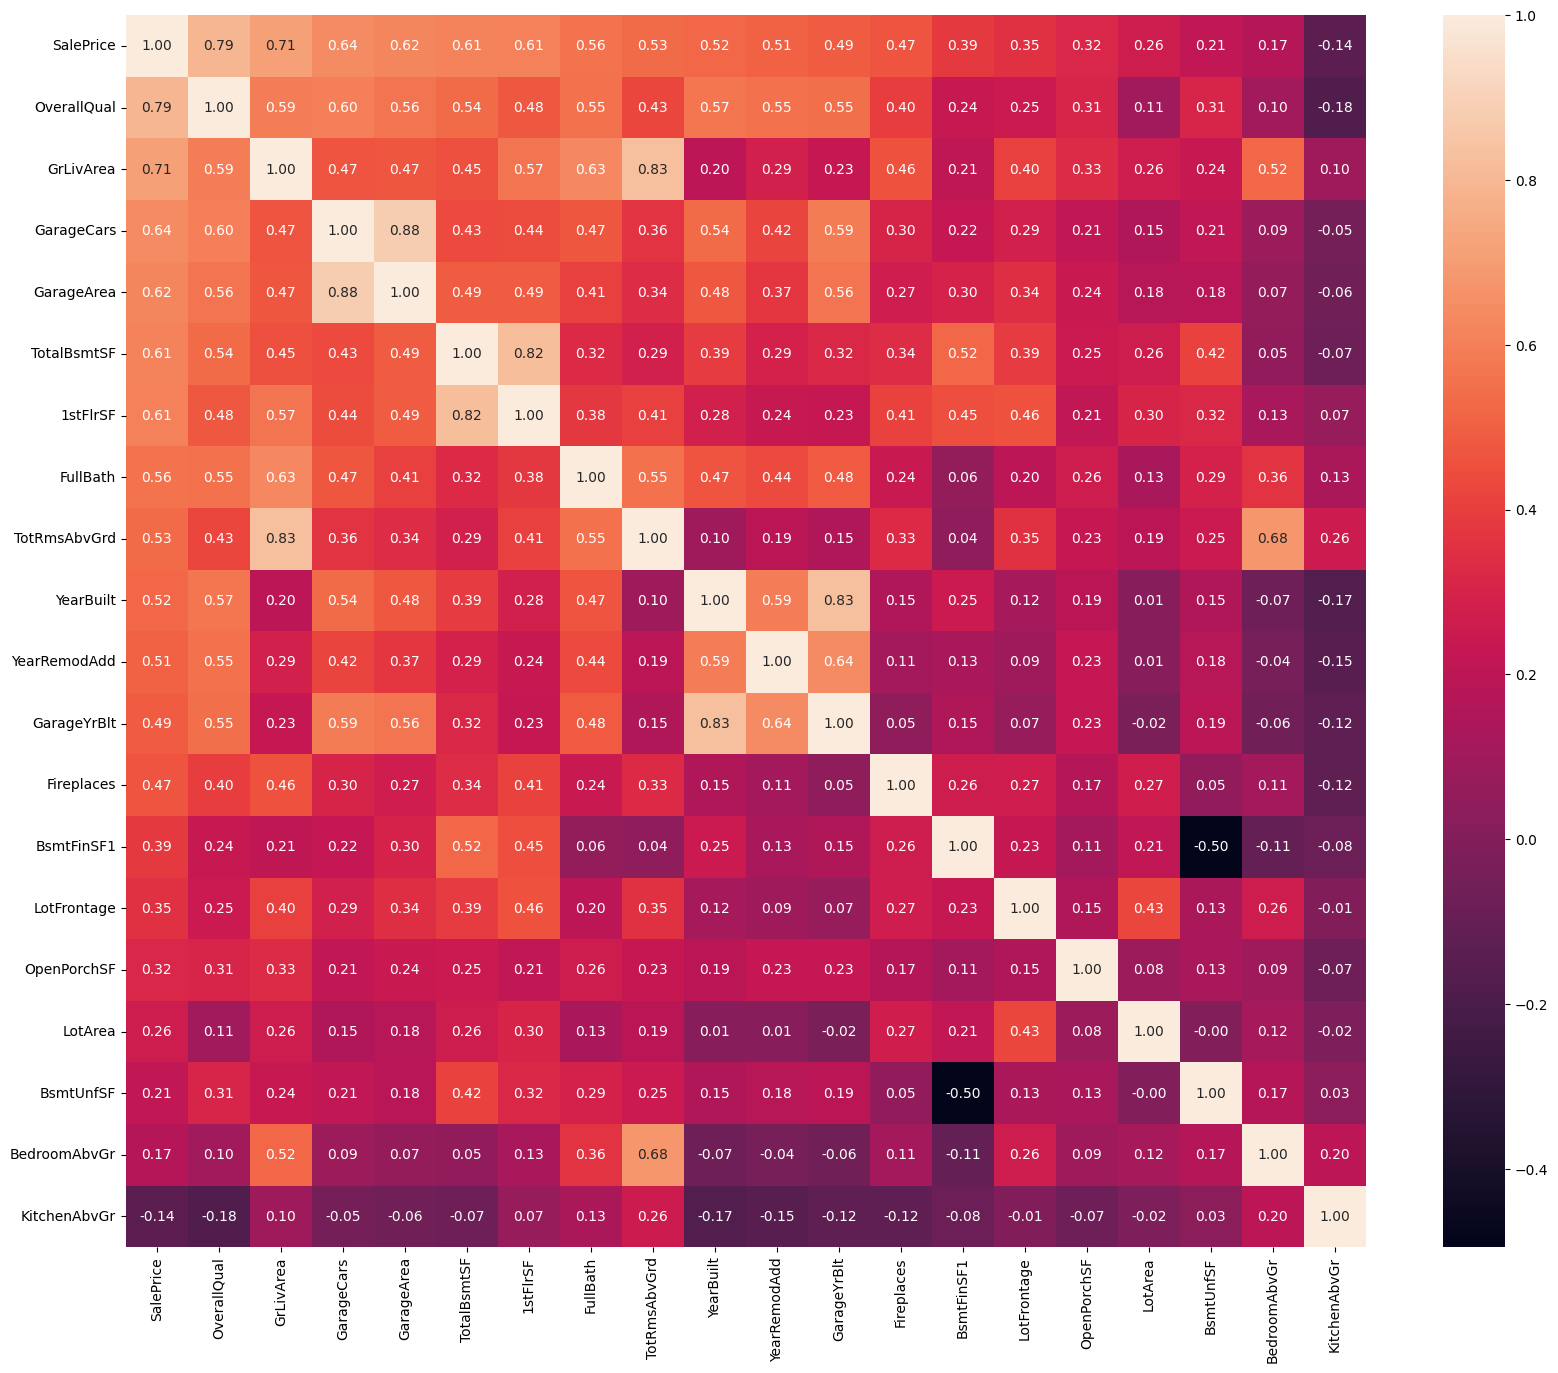

In [117]:
feature_number = correlations[correlations.abs() > 0.1].index.tolist()
plt.figure(figsize=(20, 16))
sns.heatmap(df_output[feature_number].corr(), annot=True, fmt=".2f")
np.unique(feature_number)

In [115]:
d

NameError: name 'd' is not defined

## Xử lý feature_object


In [ ]:
feature_object = df_output.select_dtypes(include=['object']).columns.tolist()
feature_object

['MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [ ]:
for col in feature_object:
    print(f"--- {col} ---")
    counts = df_output[col].value_counts().head(5)
    percents = df_output[col].value_counts(normalize=True)
    print(pd.DataFrame({"count": counts, "percent": percents}))
    print("\n")


--- MSZoning ---
          count   percent
MSZoning                 
RL         1151  0.788356
RM          218  0.149315
FV           65  0.044521
RH           16  0.010959
C (all)      10  0.006849


--- Street ---
        count  percent
Street                
Pave     1454  0.99589
Grvl        6  0.00411


--- LotShape ---
          count   percent
LotShape                 
Reg         925  0.633562
IR1         484  0.331507
IR2          41  0.028082
IR3          10  0.006849


--- LandContour ---
             count   percent
LandContour                 
Lvl           1311  0.897945
Bnk             63  0.043151
HLS             50  0.034247
Low             36  0.024658


--- Utilities ---
           count   percent
Utilities                 
AllPub      1459  0.999315
NoSeWa         1  0.000685


--- LotConfig ---
           count   percent
LotConfig                 
Inside      1052  0.720548
Corner       263  0.180137
CulDSac       94  0.064384
FR2           47  0.032192
FR3        

## Lưu các giá trị với tần suất của nó trong các cột object


In [ ]:
for col in feature_object:
    counts = df_output[col].value_counts().reset_index()
    counts.columns = [col, "count"]
    counts.to_csv(f"../../exps/train_03112025/features/{col}.csv", index=False)


## Tạo ra các boxplot giữa các feature_object với SalePrice


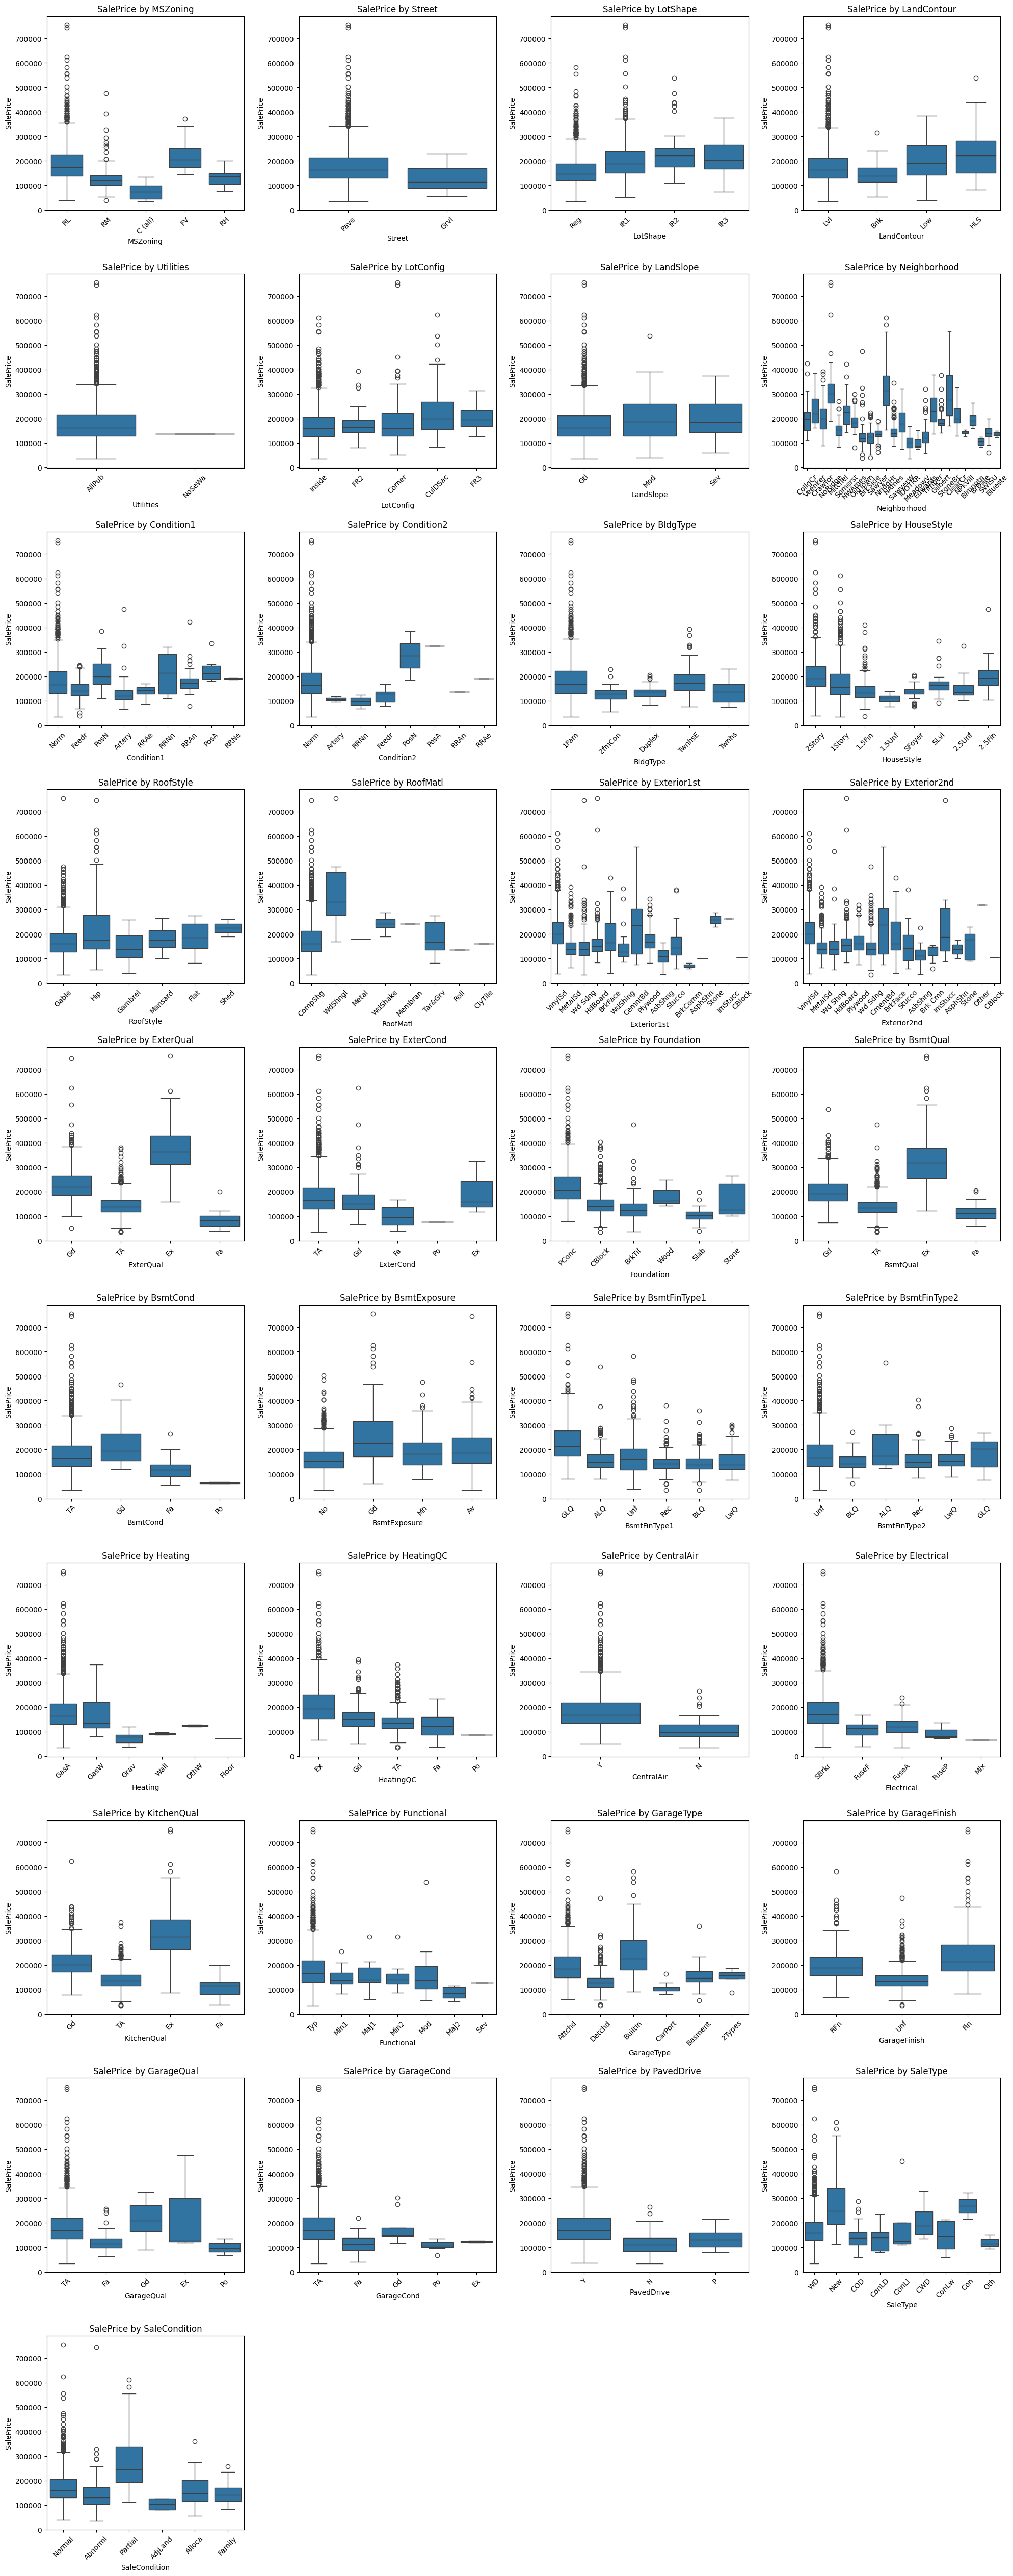

In [ ]:
# Tính toán số lượng subplot cần thiết
n_cols = len(feature_object)
n_rows = (n_cols + 2) // 3  # 3 cột mỗi hàng

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()  # Chuyển thành mảng 1 chiều để dễ duyệt

for i, col in enumerate(feature_object):
    if i < len(axes):
        sns.boxplot(x=col, y='SalePrice', data=df_output, ax=axes[i])
        axes[i].set_title(f'SalePrice by {col}')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        break

# Ẩn các subplot thừa
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Lấy ra các feature có độ phân bố ít lệch


In [ ]:
features_ob = ['BsmtExposure','BsmtFinType1','BsmtQual','Exterior1st','Exterior2nd','ExterQual','Foundation','GarageFinish','GarageType','HeatingQC','HouseStyle','KitchenQual','LandSlope','LotConfig','LotShape','MSZoning','Neighborhood','RoofStyle','SaleCondition','YrSold']

## Danh sách bộ feature dùng để train


In [ ]:
training_features = feature_number + features_ob
training_features

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt',
 'YearRemodAdd',
 'GarageYrBlt',
 'Fireplaces',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtQual',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'Foundation',
 'GarageFinish',
 'GarageType',
 'HeatingQC',
 'HouseStyle',
 'KitchenQual',
 'LandSlope',
 'LotConfig',
 'LotShape',
 'MSZoning',
 'Neighborhood',
 'RoofStyle',
 'SaleCondition',
 'YrSold']

# Khám phá dữ liệu


## 1. '1stFlrSF'


In [ ]:
df_output['1stFlrSF'].isna().sum()

np.int64(0)

-> Không có missing value


In [ ]:
df_output['1stFlrSF'].value_counts()

1stFlrSF
864     25
1040    16
912     14
894     12
848     12
        ..
1284     1
1172     1
2156     1
2053     1
992      1
Name: count, Length: 753, dtype: int64

<Axes: xlabel='1stFlrSF', ylabel='Count'>

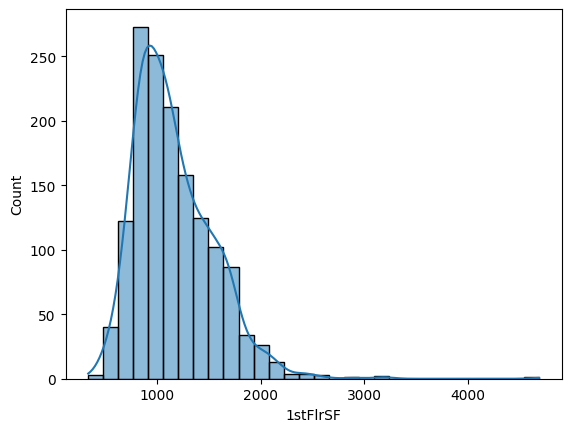

In [ ]:
sns.histplot(df_output['1stFlrSF'], kde=True, bins=30)

### Nhận xét:

Dữ liệu continuous và phân bố rộng <br>
-> Đề xuất dùng scaler để chuẩn hóa


In [ ]:
from sklearn.preprocessing import StandardScaler

def scale_features(df, feature_list, is_train=True):
    scaler = StandardScaler()
    df_scaled = df.copy()
    if is_train:
        df_scaled[feature_list] = scaler.fit_transform(df_scaled[feature_list])
    else:
        df_scaled[feature_list] = scaler.transform(df_scaled[feature_list])
    return df_scaled

## 2. 'BsmtExposure'


In [ ]:
df_output['BsmtExposure'].isna().sum()

np.int64(38)

-> Có missing value


In [ ]:
df_output.value_counts('BsmtExposure')

BsmtExposure
No    953
Av    221
Gd    134
Mn    114
Name: count, dtype: int64

In [ ]:
df_output['BsmtExposure'] = df_output['BsmtExposure'].fillna('No')

<Axes: xlabel='BsmtExposure', ylabel='Count'>

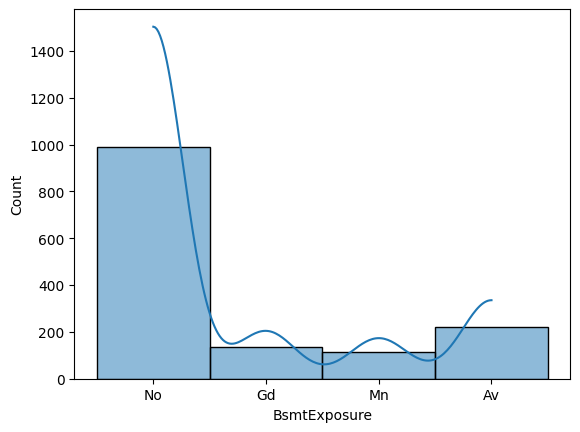

In [ ]:
sns.histplot(data=df_output, x='BsmtExposure', bins=30, kde=True)
# sns.countplot(data=df_output, x='BsmtExposure')

### Nhận xét:

- Dữ liệu categorical gồm: No, Gd, Mn, Av (No chiếm đa số) <br>
- Giá trị Gd và Mn phân bố khá đều nhau<br>
  -> Đề xuất phân loại thành 3 nhóm và chuyển thành số: 'No': 1, 'Av': 2,'Mn': 2, 'Gd': 3


In [ ]:
cls_BsmtExposure = {'No': 1, 'Av': 2,'Mn': 2, 'Gd': 3}

In [ ]:
cls_feature = {}
cls_feature['BsmtExposure'] = cls_BsmtExposure

In [ ]:
df_output['BsmtExposure'] = df_output['BsmtExposure'].map(cls_BsmtExposure)

In [ ]:
df_output.value_counts('BsmtExposure')

BsmtExposure
1    991
2    335
3    134
Name: count, dtype: int64

<Axes: xlabel='BsmtExposure', ylabel='count'>

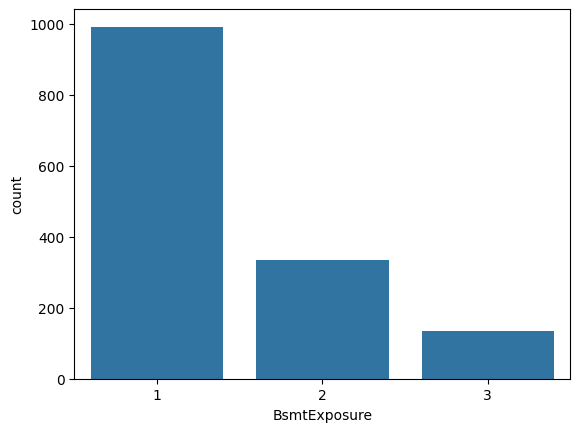

In [ ]:
sns.countplot(data=df_output, x='BsmtExposure')

## 3. 'BsmtFinType1'


In [ ]:
df_output.value_counts("BsmtFinType1")

BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
Name: count, dtype: int64

<Axes: xlabel='BsmtFinType1', ylabel='count'>

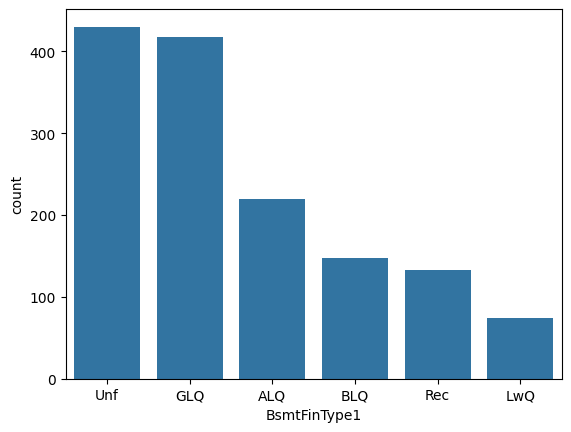

In [ ]:
# Lấy thứ tự sort theo value counts
value_order = df_output['BsmtFinType1'].value_counts().index
sns.countplot(data=df_output, x='BsmtFinType1', order=value_order)

### Nhận xét:

- Dữ liệu categorical gồm: 'Unf': 'GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ' ('GLQ' và 'ALQ' là 2 giá trị chiếm đa số) <br>
- 3 giá trị còn lại phân bố khá đều nhau<br>
  -> Đề xuất phân loại thành 3 nhóm và chuyển thành số: 'Unf': 1, 'GLQ': 2, 'ALQ': 3, 'BLQ': 3, 'Rec': 3, 'LwQ': 3


In [ ]:
cls_BsmtFinType1 = {'Unf': 1, 'GLQ': 2, 'ALQ': 3, 'BLQ': 3, 'Rec': 3, 'LwQ': 3}

In [ ]:
cls_feature['BsmtFinType1'] = cls_BsmtFinType1

In [ ]:
df_output['BsmtFinType1'] = df_output['BsmtFinType1'].map(cls_BsmtFinType1)

<Axes: xlabel='BsmtFinType1', ylabel='count'>

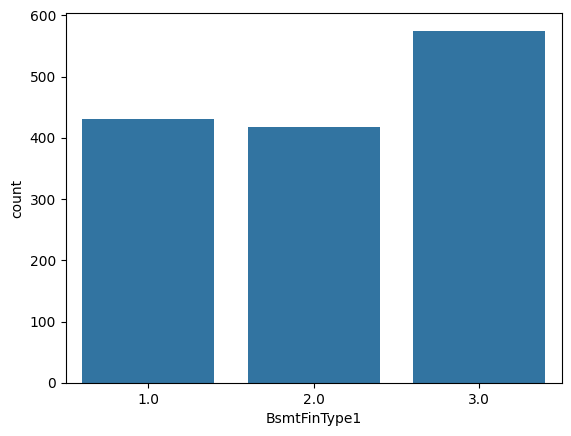

In [ ]:
sns.countplot(data=df_output, x='BsmtFinType1')

Phân bố cột BsmtFinType1 sau khi mapping: Trở thành cột categorical với 3 giá trị


## 4. 'BsmtQual'


In [ ]:
df_output['BsmtQual'].isna().sum()

np.int64(37)

In [ ]:
df_output.value_counts("BsmtQual")

BsmtQual
TA    649
Gd    618
Ex    121
Fa     35
Name: count, dtype: int64

<Axes: xlabel='BsmtQual', ylabel='count'>

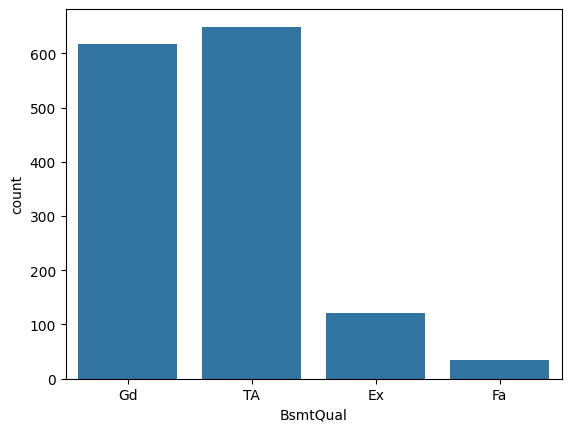

In [ ]:
# value_order = df_output['BsmtQual'].value_counts().index
sns.countplot(data=df_output, x='BsmtQual')

## Nhận xét:

- Chiều cao tầng hầm tập trung ở Gd (90-99 inches) và TA (80-89 inches)
- Fa có số lượng thấp nhất
  -> Đề xuất ta sẽ xử lý thành biến phân loại categorical
  'Ex': 1, 'Gd': 2, 'TA': 3, 'Fa': 3, 'Po': 4, 'NA': 0


In [ ]:
cls_BsmtQual = {'Ex': 1, 'Gd': 2, 'TA': 3, 'Fa': 3, 'Po': 4, 'NA': 0}

In [ ]:
cls_feature['BsmtQual'] = cls_BsmtQual

## 5. 'ExterQual'


In [ ]:
df_output['ExterQual'].isna().sum()

np.int64(0)

In [ ]:
df_output['ExterQual'].value_counts()

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

<Axes: xlabel='ExterQual', ylabel='count'>

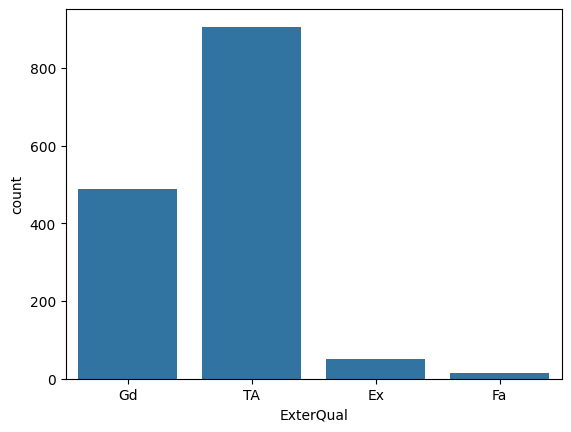

In [ ]:
sns.countplot(data=df_output, x='ExterQual')

## Nhận xét:

- Tập trung nhiều ở Gd và TA <br>
  -> Đề xuất thêm mã hóa thành các số


In [ ]:
cls_ExterQual = {'Ex': 1, 'Gd': 2, 'TA': 3, 'Fa': 4, 'Po': 5}

In [ ]:
cls_feature['ExterQual'] = cls_ExterQual

## 6. 'Exterior1st'


In [ ]:
df_output['Exterior1st'].isna().sum()

np.int64(0)

In [ ]:
df_output['Exterior1st'].value_counts()

Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64

<Axes: xlabel='Exterior1st', ylabel='Count'>

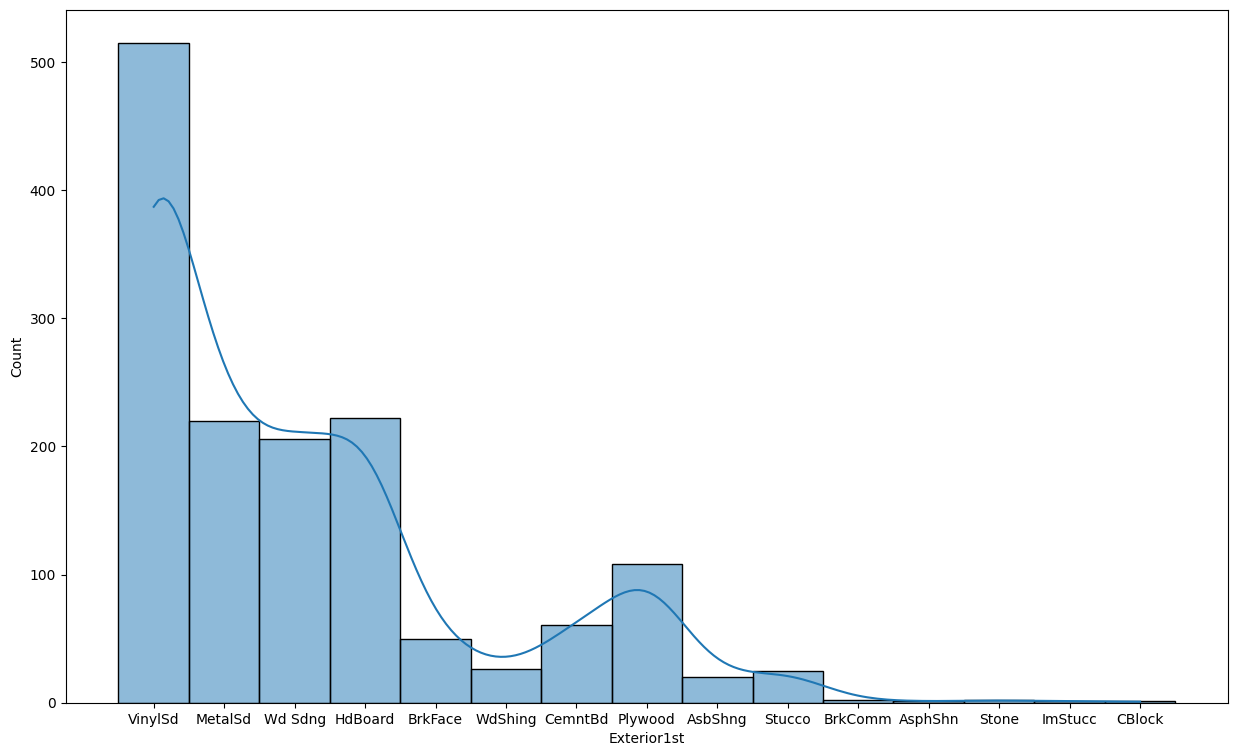

In [ ]:
plt.figure(figsize=(15,9))
sns.histplot(data=df_output, x='Exterior1st', kde=True)

## Nhận xét:

- Dữ liệu có tập giá trị khác rộng <br>
  -> Đề xuát: Từ hisplot ta có thể chia thành 4 nhóm khác nhau: Nhóm 1 (VinylSd); Nhóm 2 (MetalSd, Wd Sdng, HdBoard, Plywood), Nhóm 3 (BrkFace, WdShing, CemntBd, AsbShng, Stucco), Nhóm 4 (Others)


In [ ]:
cls_Exterior1st = {
    'VinylSd': 1,
    'MetalSd': 2,
    'Wd Sdng': 2,
    'HdBoard': 2,
    'Plywood': 2,
    'BrkFace': 3,
    'WdShing': 3,
    'CemntBd': 3,
    'AsbShng': 3,
    'Stucco': 3,
    'Others': 4,}

In [ ]:
cls_feature['Exterior1st'] = cls_Exterior1st

## 7. 'Exterior2nd'


In [ ]:
df_output['Exterior2nd'].isna().sum()

np.int64(0)

In [ ]:
df_output['Exterior2nd'].value_counts()

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

<Axes: xlabel='Exterior2nd', ylabel='Count'>

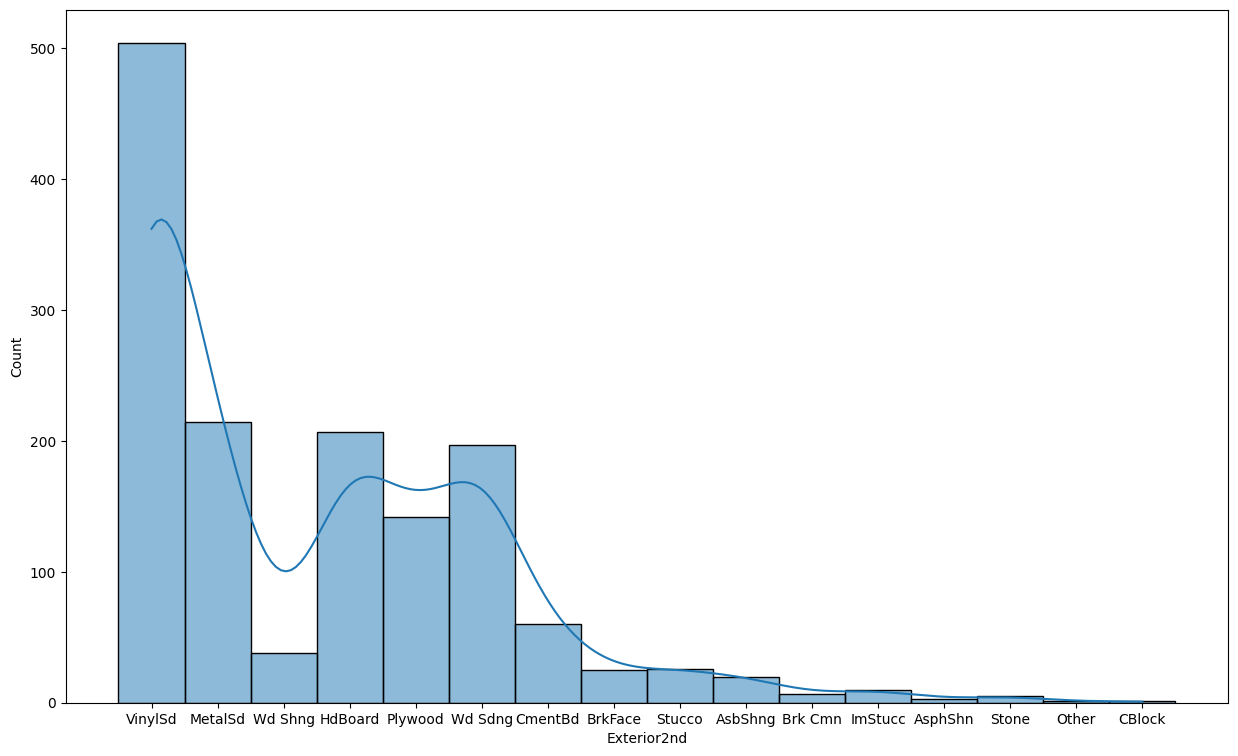

In [ ]:
plt.figure(figsize=(15,9))
sns.histplot(data=df_output, x='Exterior2nd', kde=True)

## Nhận xét:

- Dữ liệu có tập giá trị khá rộng <br>
  -> Đề xuất chỉnh thành cột phân loại categorical thành 4 nhóm: Nhóm 1 (VinylSd), Nhóm 2 (MetalSd, HdBoard, Plywood, Wd Sgmg,), Nhóm 3 (Wd Shng, BrkFace, CmentBd, Stucco, AsbShng)


In [ ]:
cls_Exterior2nd = {
    'VinylSd': 1,
    'MetalSd': 2,
    'HdBoard': 2,
    'Plywood': 2,
    'Wd Sgmg': 2,
    'Wd Shng': 3,
    'BrkFace': 3,
    'CmentBd': 3,
    'Stucco': 3,
    'AsbShng': 3,
    'Others': 4
    }

In [ ]:
cls_feature['Exterior2nd'] = cls_Exterior2nd

## 8. 'Fireplaces'


In [ ]:
df_output['Fireplaces'].isna().sum()

np.int64(0)

In [ ]:
df_output['Fireplaces'].value_counts()

Fireplaces
0    690
1    650
2    115
3      5
Name: count, dtype: int64

<Axes: xlabel='Fireplaces', ylabel='Count'>

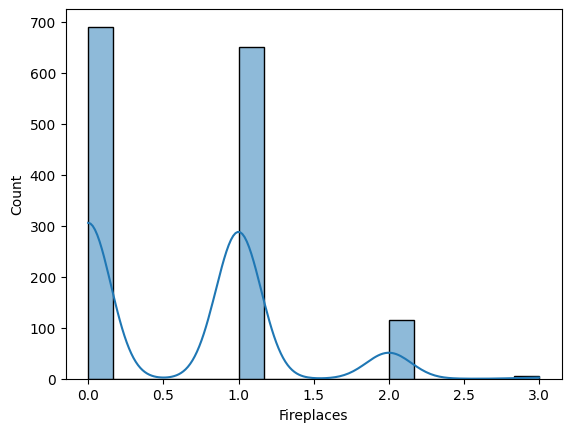

In [ ]:
sns.histplot(data=df_output, x='Fireplaces', kde=True)

## Nhận xét:

- Số lượng lò sưởi phân bố từ 0 - 3
- 0 và 1 và 2 giá trị có nhiều người nhất
  -> Đề xuất dùng scaler để chuẩn hóa giá trị


## 9. 'Foundation'


In [ ]:
df_output['Foundation'].isna().sum()

np.int64(0)

In [ ]:
df_output['Foundation'].value_counts()

Foundation
PConc     647
CBlock    634
BrkTil    146
Slab       24
Stone       6
Wood        3
Name: count, dtype: int64

<Axes: xlabel='Foundation', ylabel='Count'>

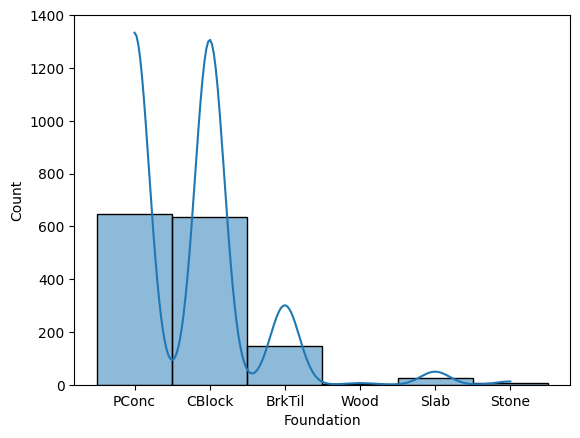

In [ ]:
sns.histplot(data=df_output, x='Foundation', kde=True)

## Nhận xét:

- Dữ liệu dạng category, phổ biến là 'PConc' và 'CBlock'
  <br>-> Đề xuất chia làm 4 nhóm và mã hóa thành số


In [ ]:
cls_Foundation = {
    'PConc': 1,
    'CBlock':2,
    'BrkTil':3,
    'Others':4
}

In [ ]:
cls_feature['Foundation'] = cls_Foundation

## 10. 'FullBath'


In [ ]:
df_output['FullBath'].isna().sum()

np.int64(0)

In [ ]:
df_output['FullBath'].value_counts()

FullBath
2    768
1    650
3     33
0      9
Name: count, dtype: int64

<Axes: xlabel='FullBath', ylabel='Count'>

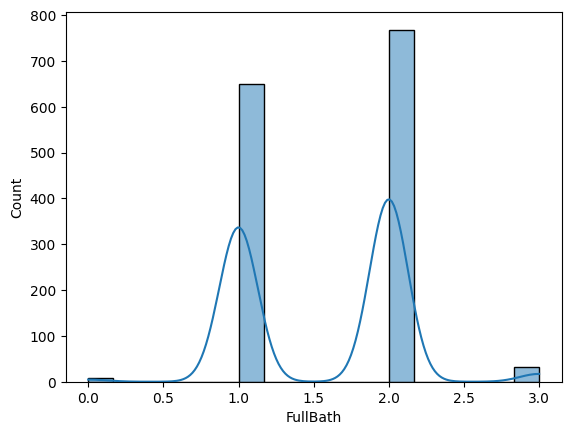

In [ ]:
sns.histplot(data=df_output, x='FullBath', kde=True)

## Nhận xét:

- Phân bố giá trị từ 0 - 3
- Tạm giữ cột này


## 11. 'GarageArea'


In [ ]:
df_output['GarageArea'].isna().sum()

np.int64(0)

In [ ]:
df_output['GarageArea'].value_counts()

GarageArea
0       81
440     49
576     47
240     38
484     34
        ..
370      1
1069     1
372      1
923      1
192      1
Name: count, Length: 441, dtype: int64

<Axes: xlabel='GarageArea', ylabel='Count'>

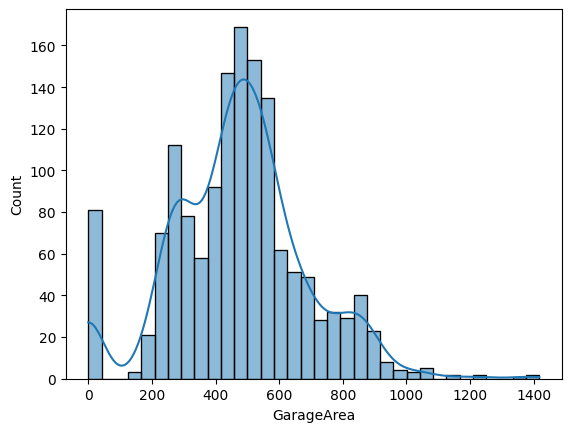

In [ ]:
sns.histplot(data=df_output, x='GarageArea', kde=True)

## Nhận xét:

- Dữ liệu phân bố khá đều
  <br> -> Cut thành các nhóm có bins = [-1, 150, 350, 600, 1000, 2000]


In [ ]:
def cut_GarageArea(x):
    if x <= 150:
        return 1
    elif x <= 350:
        return 2
    elif x <= 600:
        return 3
    elif x <= 1000:
        return 4
    else:
        return 5

In [ ]:
cut_feature = {}
cut_feature['GarageArea'] = cut_GarageArea

## 12. 'GarageCars'


In [ ]:
df_output['GarageCars'].isna().sum()

np.int64(0)

In [ ]:
df_output['GarageCars'].value_counts()  

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

<Axes: xlabel='GarageCars', ylabel='Count'>

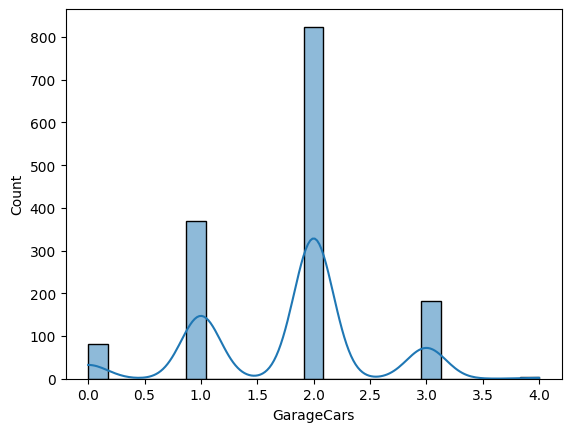

In [ ]:
sns.histplot(data=df_output, x='GarageCars', kde=True)

## Nhận xét:

- Dữ liệu phân bố từ 0 - 4. Phổ biến nhất là giá trị 2
- Tạm thời giữ nguyên cột này


## 13. 'GarageFinish'


In [ ]:
df_output['GarageFinish'].isna().sum()

np.int64(81)

In [ ]:
df_output['GarageFinish'].value_counts()

GarageFinish
Unf    605
RFn    422
Fin    352
Name: count, dtype: int64

<Axes: xlabel='GarageFinish', ylabel='Count'>

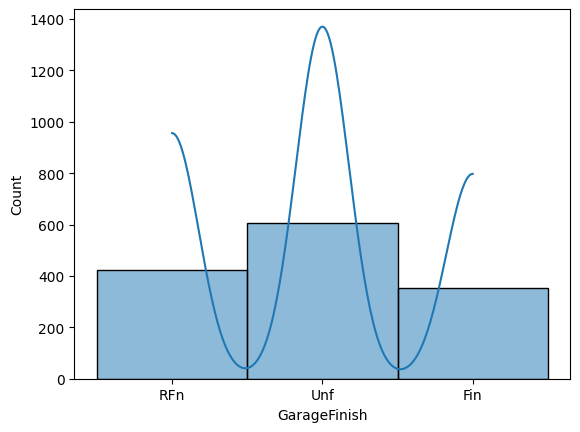

In [ ]:
sns.histplot(data=df_output, x='GarageFinish', kde=True)

## Nhận xét:

- Dữ liệu dạng categorical với 3 giá trị: RFn, Unf, Fin
  <br> -> Đề xuất mã hóa thành số


In [ ]:
cls_GarageFinish = {
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

In [ ]:
cls_feature['GarageFinish'] = cls_GarageFinish

## 14. 'GarageType'


In [ ]:
df_output['GarageType'].isna().sum()

np.int64(81)

In [ ]:
df_output['GarageType'].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

<Axes: xlabel='GarageType', ylabel='Count'>

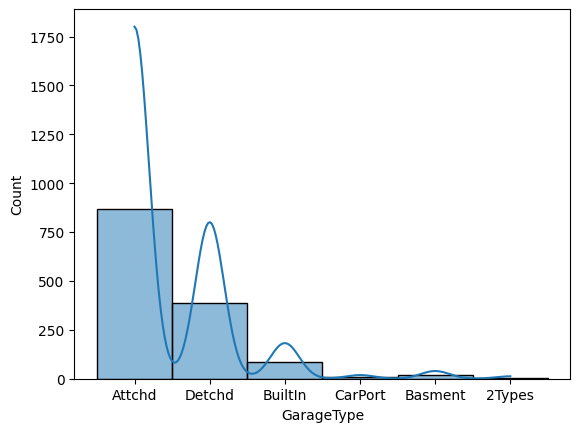

In [ ]:
sns.histplot(data=df_output, x='GarageType', kde=True)

## Nhận xét:

- Dữ liệu dạng categorical với 6 giá trị
- Có 3 giá trị có tần suất khá thấp
  <br>-> Chia làm 4 khoảng và mã hóa thành số


In [ ]:
cls_GarageType = {
    'Attchd': 1,
    'Detchd': 2,
    'BuiltIn': 3,
    'CarPort': 4,
    'Basment': 4,
    '2Types': 4
}

In [ ]:
cls_feature['GarageType'] = cls_GarageType

## 15. 'GarageYrBlt'


In [ ]:
df_output['GarageYrBlt'].isna().sum()

np.int64(81)

In [ ]:
df_output['GarageYrBlt'].value_counts()

GarageYrBlt
2005.0    65
2006.0    59
2004.0    53
2003.0    50
2007.0    49
          ..
1900.0     1
1927.0     1
1906.0     1
1908.0     1
1933.0     1
Name: count, Length: 97, dtype: int64

In [ ]:
df_output['GarageYrBlt'].describe()

count    1379.000000
mean     1978.506164
std        24.689725
min      1900.000000
25%      1961.000000
50%      1980.000000
75%      2002.000000
max      2010.000000
Name: GarageYrBlt, dtype: float64

<Axes: xlabel='GarageYrBlt', ylabel='Count'>

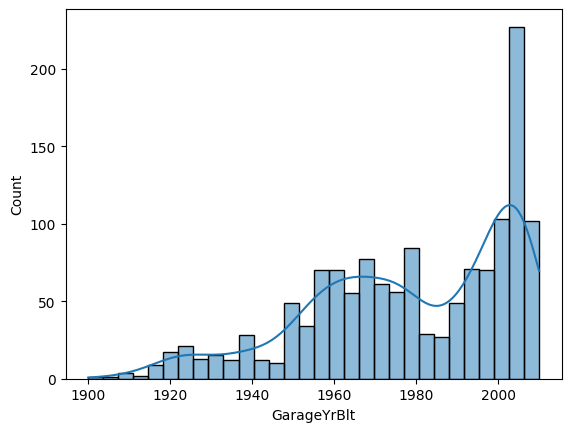

In [ ]:
sns.histplot(data=df_output, x='GarageYrBlt', kde=True, bins=30)

## Nhận xét:

- Số lượng Garage được xây dựng nhiều ở những năm 1990-2000
  <br> -> Đề xuất chia ra thành 3 khoảng


In [ ]:
def cut_GarageYrBlt(x):
    if x >= 1900 and x < 1940:
        return 1
    elif x >= 1940 and x < 1990:
        return 2
    elif x >= 1990 and x <= 2025:
        return 3
    else:
        return 4

In [ ]:
cut_feature['GarageYrBlt'] = cut_GarageYrBlt

## 16. 'GrLivArea'


In [ ]:
df_output['GrLivArea'].isna().sum()

np.int64(0)

In [ ]:
df_output['GrLivArea'].value_counts()

GrLivArea
864     22
1040    14
894     11
1456    10
848     10
        ..
1687     1
2482     1
1912     1
1584     1
1746     1
Name: count, Length: 861, dtype: int64

In [ ]:
df_output['GrLivArea'].describe()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

<Axes: xlabel='GrLivArea', ylabel='Count'>

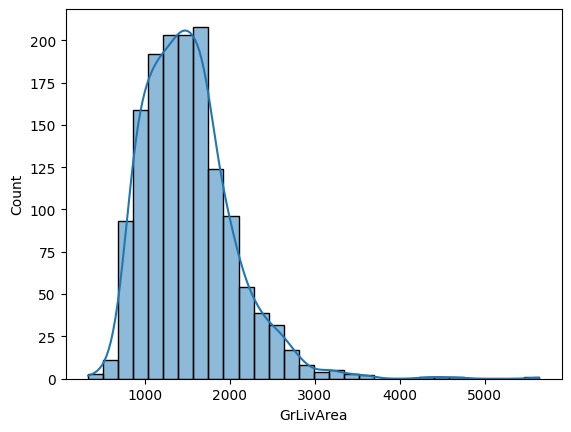

In [ ]:
sns.histplot(data=df_output, x='GrLivArea', kde=True, bins=30)

## Nhận xét:

- Dữ liệu phân bố khá đều
  <br> -> Có thể chia ra thành 4 khoảng: bins = [300,550,2050,8000]


In [ ]:
def cut_GrLivArea(x):
    if x >= 300 and x < 550:
        return 1
    elif x >= 550 and x < 2050:
        return 2
    elif x >= 2050 and x < 8000:
        return 3
    else:
        return 4

In [ ]:
cut_feature['GrLivArea'] = cut_GrLivArea

## 17. 'HeatingQC'


In [ ]:
df_output['HeatingQC'].isna().sum()

np.int64(0)

In [ ]:
df_output['HeatingQC'].value_counts()

HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

<Axes: xlabel='HeatingQC', ylabel='Count'>

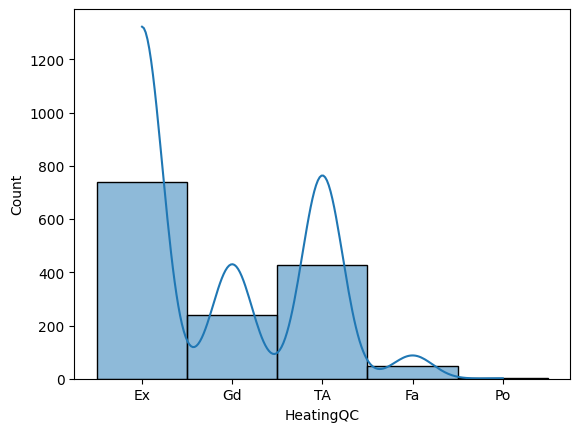

In [ ]:
sns.histplot(data=df_output, x='HeatingQC', kde=True)

## Nhận xét:

- Dữ liệu dạng Categorical gồm 5 giá trị
  <br>-> Đề xuất mã hóa ra số


In [ ]:
cls_HeatingQC = {
    'Ex': 1,
    'Gd': 2,
    'TA': 3,
    'Fa': 4,
    'Po': 5
}

In [ ]:
cls_feature['HeatingQC'] = cls_HeatingQC

## 18. 'HouseStyle'


In [ ]:
df_output['HouseStyle'].isna().sum()

np.int64(0)

In [ ]:
df_output['HouseStyle'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2Story
1       1Story
2       2Story
3       2Story
4       2Story
         ...  
1455    2Story
1456    1Story
1457    2Story
1458    1Story
1459    1Story
Name: HouseStyle, Length: 1460, dtype: object>

<Axes: xlabel='HouseStyle', ylabel='Count'>

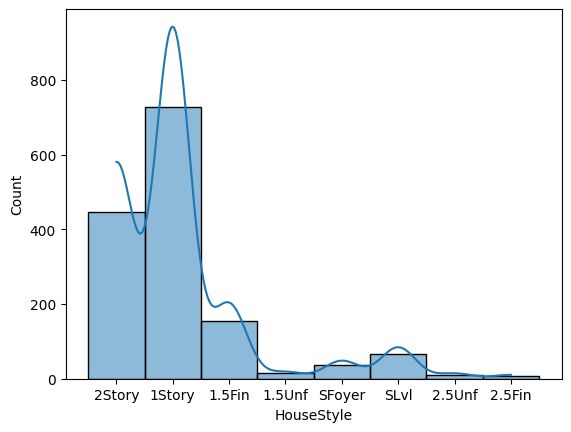

In [ ]:
sns.histplot(data=df_output, x='HouseStyle', kde=True, bins=30)

## Nhận xét:

- Dữ liệu phân bố không đồng đều, tập trung vào '2Story', '1Story', '1.5Fin'
  <br>-> Đề xuất chia thành 4 nhóm '2Story', '1Story', '1.5Fin' và 'Others'


In [ ]:
cls_HouseStyle = {
    '1Story': 1,
    '2Story': 2,
    '1.5Fin': 3,
    'Others': 4
}

In [ ]:
cls_feature['HouseStyle'] = cls_HouseStyle

## 19. 'KitchenQual'


In [ ]:
df_output['KitchenQual'].isna().sum()

np.int64(0)

In [ ]:
df_output['KitchenQual'].value_counts()

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

In [ ]:
df_output['KitchenQual'].describe()

count     1460
unique       4
top         TA
freq       735
Name: KitchenQual, dtype: object

<Axes: xlabel='KitchenQual', ylabel='Count'>

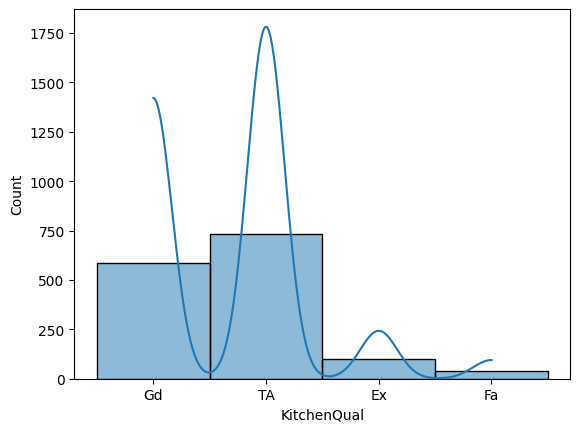

In [ ]:
sns.histplot(data=df_output, x='KitchenQual', kde=True)

## Nhận xét:

- Dữ liệu categorical
  -> Đề xuất mã hóa thành số


In [ ]:
cls_KitchenQual = {
    'Ex': 1,
    'Gd': 2,
    'TA': 3,
    'Fa': 4,
    'Po': 5
}

In [ ]:
cls_feature['KitchenQual'] = cls_KitchenQual

## 20. 'LandSlope'


In [ ]:
df_output['LandSlope'].isna().sum()

np.int64(0)

In [ ]:
df_output['LandSlope'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Gtl
1       Gtl
2       Gtl
3       Gtl
4       Gtl
       ... 
1455    Gtl
1456    Gtl
1457    Gtl
1458    Gtl
1459    Gtl
Name: LandSlope, Length: 1460, dtype: object>

<Axes: xlabel='LandSlope', ylabel='Count'>

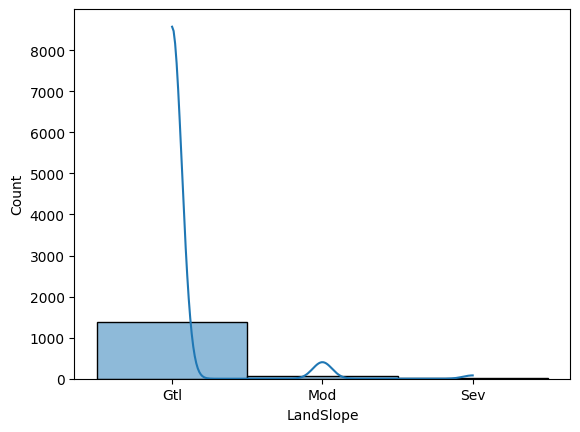

In [ ]:
sns.histplot(data=df_output, x='LandSlope', kde=True)

## Nhận xét:

- Dữ liệu lệch hẳn về Gtl
- Mất cân bằng
  -> Đề xuất drop


In [ ]:
# drop_cols = ['LandSlope']
if 'LandSlope' in final_feature:
    final_feature.remove('LandSlope')

## 21. 'LotConfig'


In [ ]:
df_output['LotConfig'].isna().sum()

np.int64(0)

In [ ]:
df_output['LotConfig'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Inside
1          FR2
2       Inside
3       Corner
4          FR2
         ...  
1455    Inside
1456    Inside
1457    Inside
1458    Inside
1459    Inside
Name: LotConfig, Length: 1460, dtype: object>

<Axes: xlabel='LotConfig', ylabel='Count'>

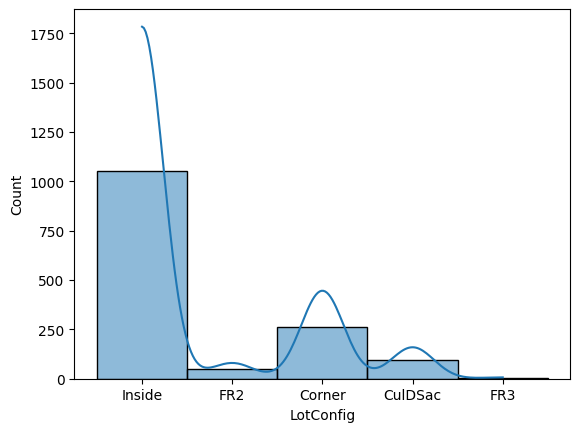

In [ ]:
sns.histplot(data=df_output, x='LotConfig', kde=True)

## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Inside' và 'Corner'
  <br>-> Đề xuất tạo 3 nhóm vào mã hóa thành số


In [ ]:
cls_LotConfig = {
    'Inside': 1,
    'Corner': 2,
    'others': 3
}

In [ ]:
cls_feature['LotConfig'] = cls_LotConfig

## 22. 'LotShape'


In [ ]:
df_output['LotShape'].isna().sum()

np.int64(0)

In [ ]:
df_output['LotShape'].value_counts()

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

<Axes: xlabel='LotShape', ylabel='Count'>

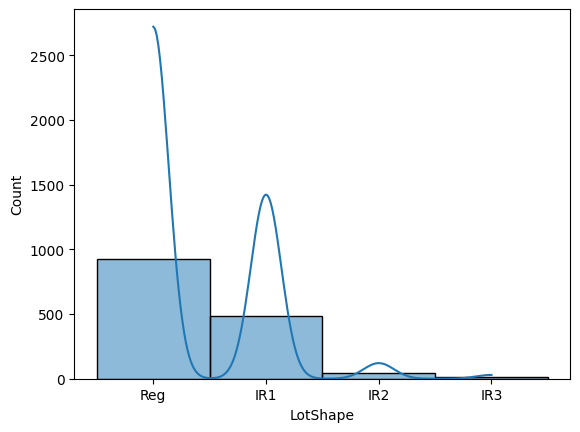

In [ ]:
sns.histplot(data=df_output, x='LotShape', kde=True)

## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Reg' và 'IR1'
  <br>-> Đề xuất tạo 3 nhóm và mã hóa thành số


In [ ]:
cls_LotShape = {
    'Reg': 1,
    'IR3': 2,
    'Others': 3
}

In [ ]:
cls_feature['LotShape'] = cls_LotShape

## 23. 'MSZoning'


In [ ]:
df_output['MSZoning'].isna().sum()

np.int64(0)

In [ ]:
df_output['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

<Axes: xlabel='MSZoning', ylabel='Count'>

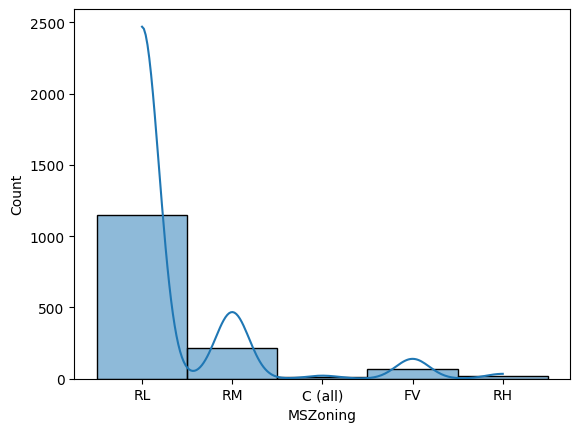

In [ ]:
sns.histplot(data=df_output, x='MSZoning', kde=True)

## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'RL' và 'RM'
  <br>-> Đề xuất tạo 3 nhóm vào mã hóa thành số


In [ ]:
cls_MSZoning = {
    'RL': 1,
    'RM': 2,
    'Others': 3
}

In [ ]:
cls_feature['MSZoning'] = cls_MSZoning

## 24. 'Neighborhood'


In [ ]:
df_output['Neighborhood'].isna().sum()

np.int64(0)

In [ ]:
df_output['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

<Axes: xlabel='Neighborhood', ylabel='count'>

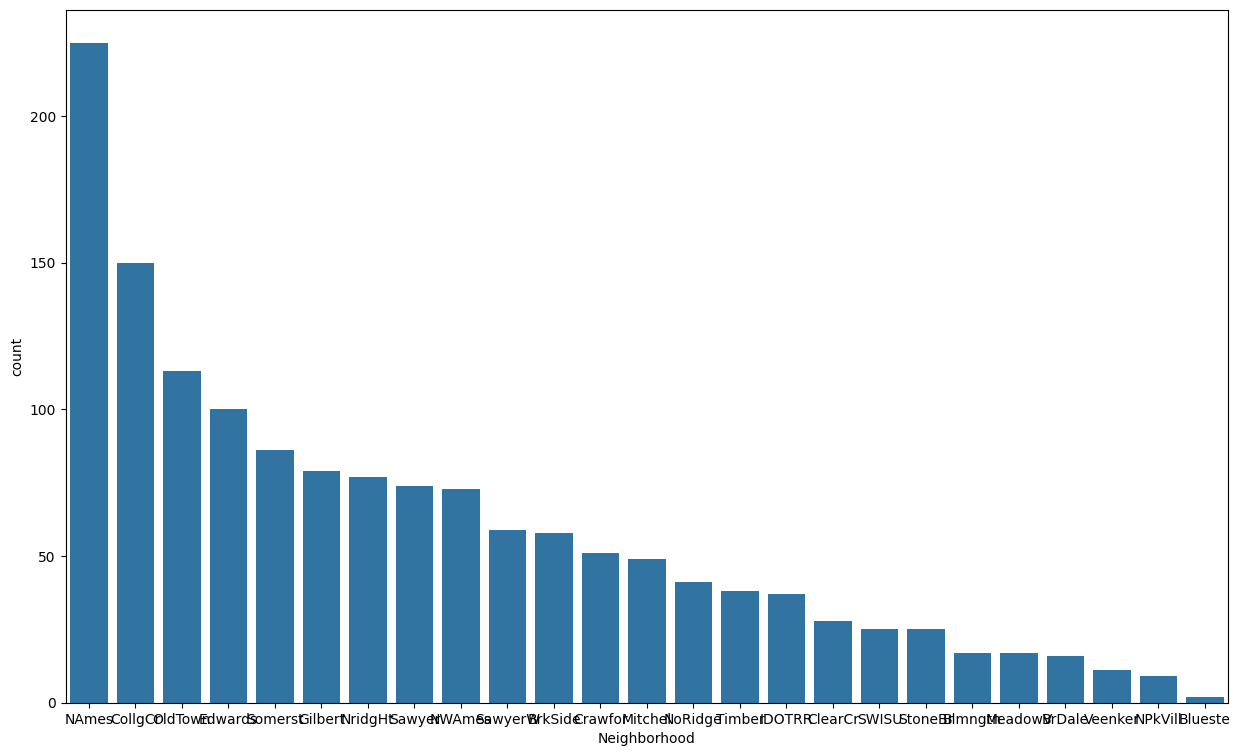

In [ ]:
plt.figure(figsize=(15,9))
value_order = df_output['Neighborhood'].value_counts().index
sns.countplot(data=df_output, x='Neighborhood', order=value_order)

## Nhận xét:

- Dữ liệu có tập giá trị khá rộng
- Có thể sử dụng TargetEncoder để mã hóa


In [ ]:
!pip install category_encoders


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from category_encoders import TargetEncoder
# def target_encode_feature(df, feature_name, target_name='SalePrice', is_train=True):
#     encoder = TargetEncoder()
#     if is_train:
#         df[feature_name] = encoder.fit_transform(df[feature_name], df[target_name])
#     else:
#         df[feature_name] = encoder.transform(df[feature_name])
#     return df

In [ ]:
def target_encode_feature_(df_train, df_test, feature_name, target_name='SalePrice'):
    encoder = TargetEncoder()
    df_train[feature_name] = encoder.fit_transform(df_train[feature_name], df_train[target_name])
    df_test[feature_name] = encoder.transform(df_test[feature_name])
    return df_train, df_test

## 25. 'OverallQual'


In [ ]:
df_output['OverallQual'].isna().sum()

np.int64(0)

In [ ]:
df_output['OverallQual'].value_counts() 

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

<Axes: xlabel='OverallQual', ylabel='Count'>

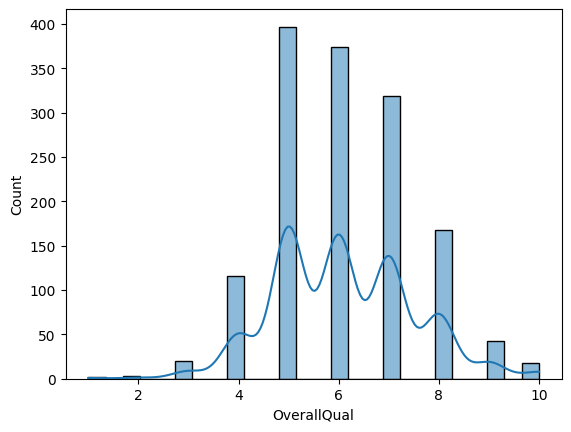

In [ ]:
sns.histplot(data=df_output, x='OverallQual', kde=True)

## Nhận xét:

- Dữ liệu phân bố tập trung từ 5-8
  <br> -> Có thể tách ra thành 3 khoảng


In [ ]:
def cut_OverallQual(x):
    if x <= 4:
        return 1
    elif x >= 5 and x <= 8:
        return 2
    else:
        return 3

In [ ]:
cut_feature['OverallQual'] = cut_OverallQual

## 26. 'RoofStyle'


In [ ]:
df_output['RoofStyle'].isna().sum()

np.int64(0)

In [ ]:
df_output['RoofStyle'].value_counts()

RoofStyle
Gable      1141
Hip         286
Flat         13
Gambrel      11
Mansard       7
Shed          2
Name: count, dtype: int64

<Axes: xlabel='RoofStyle', ylabel='Count'>

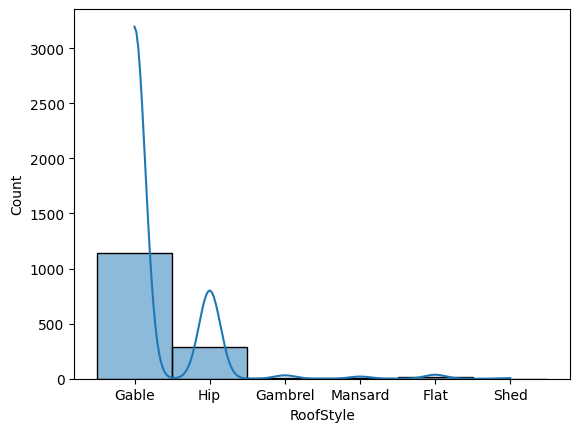

In [ ]:
sns.histplot(data=df_output, x='RoofStyle', kde=True)

## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Gable' và 'Hip'
  <br>-> Đề xuất tạo 3 nhóm vào mã hóa thành số


In [ ]:
cls_RoofStyle = {
    'Gable':1,
    'Hip': 2,
    'Others':3
}

In [ ]:
cls_feature['RoofStyle'] = cls_RoofStyle

## 27. 'SaleCondition'


In [ ]:
df_output['SaleCondition'].isna().sum()

np.int64(0)

In [ ]:
df_output['SaleCondition'].value_counts()

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

<Axes: xlabel='SaleCondition', ylabel='Count'>

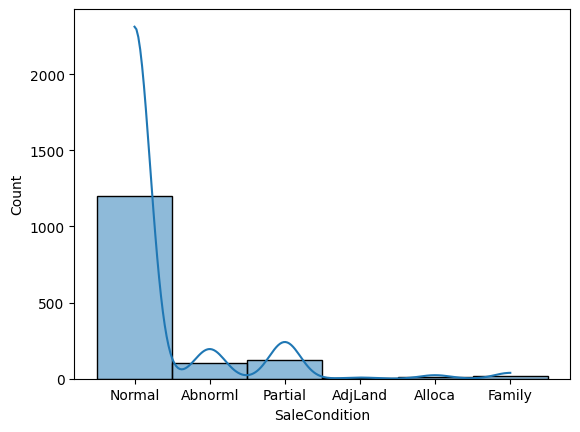

In [ ]:
sns.histplot(data=df_output, x='SaleCondition', kde=True)

## Nhận xét:

- Dữ liệu categorical và phân bổ tập trung ở 'Normal', 'Abnorml' và 'Partial'
  <br>-> Đề xuất tạo 4 nhóm vào mã hóa thành số


In [ ]:
cls_SaleCondition = {
    'Normal': 1,
    'Partial': 2,
    'Abnorml':3,
    'Others': 4

}

In [ ]:
cls_feature['SaleCondition'] = cls_SaleCondition

## 28. 'TotRmsAbvGrd'


In [ ]:
df_output['TotRmsAbvGrd'].isna().sum()

np.int64(0)

In [ ]:
df_output['TotRmsAbvGrd'].value_counts()    

TotRmsAbvGrd
6     402
7     329
5     275
8     187
4      97
9      75
10     47
11     18
3      17
12     11
2       1
14      1
Name: count, dtype: int64

<Axes: xlabel='TotRmsAbvGrd', ylabel='Count'>

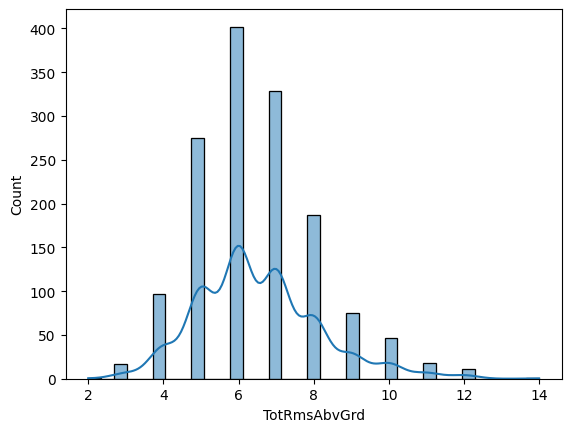

In [ ]:
sns.histplot(data=df_output, x='TotRmsAbvGrd', kde=True)

## Nhận xét:

- Dữ liệu phân bố tập trung từ 5-7
  <br> -> Có thể tách ra thành 3 khoảng


In [ ]:
def cut_TotRmsAbvGrd(x):
    if x <= 4:
        return 1
    elif x >= 5 and x <= 7:
        return 2
    else:
        return 3

In [ ]:
cut_feature['TotRmsAbvGrd'] = cut_TotRmsAbvGrd

## 29. 'TotalBsmtSF'


In [ ]:
df_output['TotalBsmtSF'].isna().sum()

np.int64(0)

In [ ]:
df_output['TotalBsmtSF'].value_counts()

TotalBsmtSF
0       37
864     35
672     17
912     15
1040    14
        ..
1525     1
482      1
1542     1
839      1
1286     1
Name: count, Length: 721, dtype: int64

<Axes: xlabel='TotalBsmtSF', ylabel='Count'>

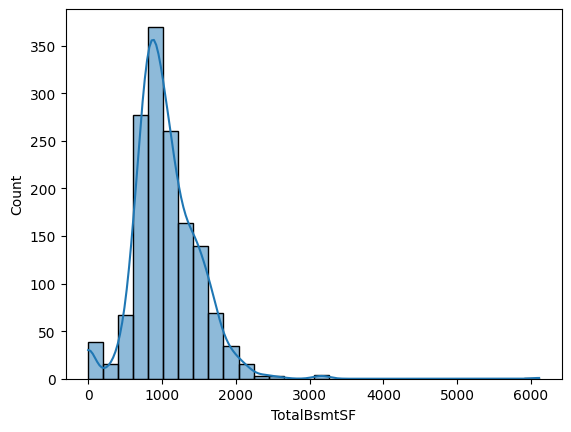

In [ ]:
sns.histplot(data=df_output, x='TotalBsmtSF', kde=True, bins=30)

## Nhận xét:

- Dữ liệu phân bố tập trung từ 600-2000
  <br> -> Đề xuất dùng scale


## 30. 'YearBuilt' và 'YrSold'


In [ ]:
df_output['YearBuilt'].isna().sum()

np.int64(0)

In [ ]:
df_output['YrSold'].isna().sum()

np.int64(0)

### Chúng ta sẽ xây dựng thuộc tính HouseAge để tính tuổi của nhà


In [ ]:
def engineer_HouseAge(df):
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    return df

## 31. 'YearRemodAdd'


In [ ]:
df_output['YearRemodAdd'].isna().sum()

np.int64(0)

### Chúng ta sẽ xây dựng thuộc tính IsRemodeled để xem căn nhà đã sửa qua chưa


In [ ]:
def engineer_IsRemodeled(df):
    df['IsRemodeled'] = np.where(df['YearRemodAdd'] != df['YearBuilt'], 1, 0)
    return df

## 32. 'CentralAir'


In [ ]:
df_output.value_counts('CentralAir')

CentralAir
Y    1365
N      95
Name: count, dtype: int64

<Axes: xlabel='CentralAir', ylabel='Count'>

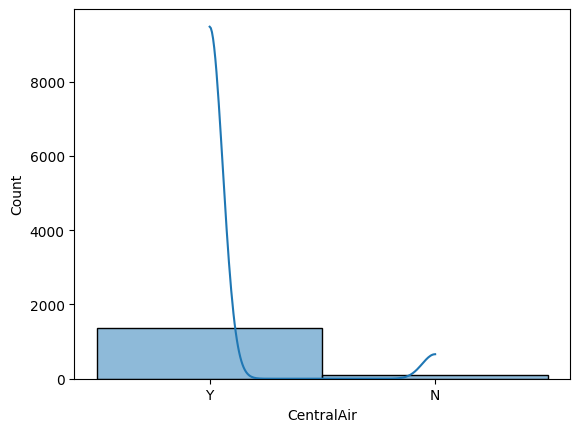

In [ ]:
sns.histplot(data=df_output, x='CentralAir', kde=True)

In [ ]:
cls_CentralAir = {
    'Y': 1,
    'N': 0
}

In [ ]:
df_output['CentralAir'] = df_output['CentralAir'].map(cls_CentralAir)

## 33. 'Electrical'


In [ ]:
df_output.value_counts('Electrical')

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

<Axes: xlabel='Electrical', ylabel='Count'>

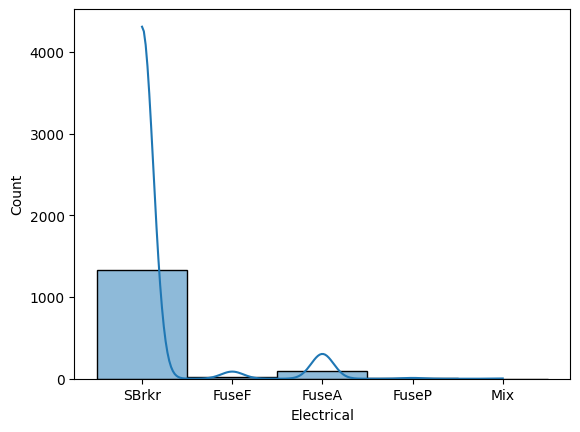

In [ ]:
sns.histplot(data=df_output, x='Electrical', kde=True)

In [ ]:
cls_Electrical = {
    'SBrkr': 1,
    'FuseA': 2,
    'Others': 3
}

In [ ]:
df_output['Electrical'] = df_output['Electrical'].map(lambda x: cls_Electrical[x] if x in cls_Electrical else cls_Electrical['Others'])

In [ ]:
df_output['Electrical'].value_counts()

Electrical
1    1334
2      94
3      32
Name: count, dtype: int64

## 34. 'PavedDrive'


In [ ]:
df_output.value_counts('PavedDrive')

PavedDrive
Y    1340
N      90
P      30
Name: count, dtype: int64

<Axes: xlabel='PavedDrive', ylabel='Count'>

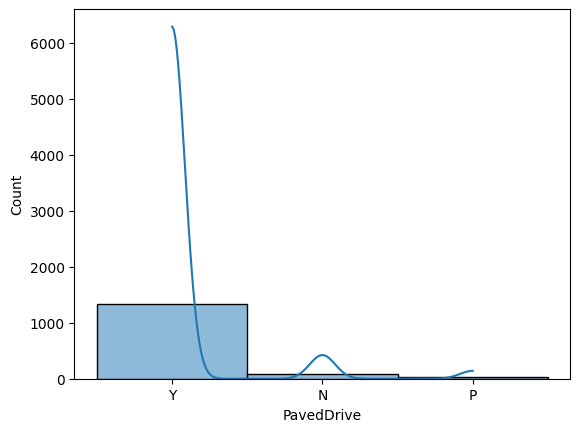

In [ ]:
sns.histplot(data=df_output, x='PavedDrive', kde=True)

In [ ]:
cls_PavedDrive = {
    'Y': 1,
    'N': 2,
    'P': 3
}   

In [ ]:
cls_feature['PavedDrive'] = cls_PavedDrive

In [ ]:
df_output['PavedDrive'] = df_output['PavedDrive'].map(cls_PavedDrive)